# **a Collège**

## grille finale

In [ ]:
import geopandas as gpd
import pandas as pd

# =========================================================
# (1) CHARGEMENT ISOCHRONES
# =========================================================
iso_file = (
    "/content/"
    "isodistance_ors_college_1_5_km_secteur.gpkg"
)

gdf_iso = gpd.read_file(iso_file)

# =========================================================
# (2) CHARGEMENT GRILLE
# =========================================================
grid_file = (
    "/content/"
    "grille_alsace_sans_massifs.gpkg"
)

gdf_grid = gpd.read_file(grid_file)

# =========================================================
# (3) MEME CRS
# =========================================================
if gdf_iso.crs != gdf_grid.crs:
    gdf_iso = gdf_iso.to_crs(gdf_grid.crs)

# =========================================================
# (4) SURFACE TOTALE DES MAILLES
# =========================================================
gdf_grid["surface_maille"] = gdf_grid.geometry.area

# =========================================================
# (5) INTERSECTION
# =========================================================
gdf = gpd.overlay(
    gdf_grid,
    gdf_iso,
    how="intersection"
)

print("Nb intersections :", len(gdf))

# =========================================================
# (6) SURFACE INTERSECTION
# =========================================================
gdf["surface_intersection"] = gdf.geometry.area

# =========================================================
# (7) SURFACE PAR MAILLE + COLLEGE + DISTANCE
# =========================================================
grouped = (
    gdf.groupby(
        [
            "idINSPIRE",
            "cea_code",
            "libelle_court",
            "AA_METERS"
        ],
        as_index=False
    )["surface_intersection"]
    .sum()
)

# =========================================================
# (8) SURFACE TOTALE PAR MAILLE + COLLEGE
# =========================================================
college_surface = (
    grouped.groupby(
        [
            "idINSPIRE",
            "cea_code",
            "libelle_court"
        ],
        as_index=False
    )["surface_intersection"]
    .sum()
    .rename(
        columns={
            "surface_intersection": "surface_college"
        }
    )
)

# =========================================================
# (9) COLLEGE MAJORITAIRE
# =========================================================
idx = (
    college_surface.groupby("idINSPIRE")
    ["surface_college"]
    .idxmax()
)

college_majoritaire = (
    college_surface.loc[idx]
    .copy()
)

# =========================================================
# (10) AJOUT SURFACE MAILLE
# =========================================================
college_majoritaire = college_majoritaire.merge(
    gdf_grid[
        [
            "idINSPIRE",
            "surface_maille"
        ]
    ],
    on="idINSPIRE",
    how="left"
)

# =========================================================
# (11) PART DE LA MAILLE COUVERTE
# =========================================================
college_majoritaire["part_majoritaire"] = (
    college_majoritaire["surface_college"]
    / college_majoritaire["surface_maille"]
)

# =========================================================
# (12) FILTRE > 50%
# =========================================================
college_majoritaire = (
    college_majoritaire[
        college_majoritaire["part_majoritaire"] > 0.5
    ]
)

print(
    "Mailles avec collège majoritaire >50% :",
    len(college_majoritaire)
)

# =========================================================
# (13) DISTANCE MINIMALE DU COLLEGE RETENU
# =========================================================
distance_min = (
    grouped.groupby(
        [
            "idINSPIRE",
            "cea_code",
            "libelle_court"
        ],
        as_index=False
    )["AA_METERS"]
    .min()
)

resultat = college_majoritaire.merge(
    distance_min,
    on=[
        "idINSPIRE",
        "cea_code",
        "libelle_court"
    ],
    how="left"
)

# =========================================================
# (14) VARIABLES DISTANCE
# =========================================================
for d in [1000, 2000, 3000, 4000, 5000]:

    resultat[f"dist_{d}"] = (
        resultat["AA_METERS"] == d
    ).astype(int)

# =========================================================
# (15) SCORE
# =========================================================
resultat["score_access"] = (
      resultat["dist_1000"] * 1.0
    + resultat["dist_2000"] * 1.0
    + resultat["dist_3000"] * 1.0
    + resultat["dist_4000"] * 0.4
    + resultat["dist_5000"] * 0.2
)

# =========================================================
# (16) UNE SEULE AFFECTATION
# =========================================================
resultat["nb_college_accessibles"] = 1

# =========================================================
# (17) TYPES
# =========================================================
gdf_grid["idINSPIRE"] = (
    gdf_grid["idINSPIRE"]
    .astype(str)
)

resultat["idINSPIRE"] = (
    resultat["idINSPIRE"]
    .astype(str)
)

# =========================================================
# (18) JOINTURE FINALE
# =========================================================
gdf_final = gdf_grid.merge(
    resultat[
        [
            "idINSPIRE",
            "cea_code",
            "libelle_court",
            "surface_college",
            "part_majoritaire",
            "AA_METERS",
            "dist_1000",
            "dist_2000",
            "dist_3000",
            "dist_4000",
            "dist_5000",
            "score_access",
            "nb_college_accessibles"
        ]
    ],
    on="idINSPIRE",
    how="left"
)

# =========================================================
# (19) NULL -> 0
# =========================================================
for c in [
    "dist_1000",
    "dist_2000",
    "dist_3000",
    "dist_4000",
    "dist_5000"
]:

    gdf_final[c] = (
        gdf_final[c]
        .fillna(0)
        .astype(int)
    )

gdf_final["score_access"] = (
    gdf_final["score_access"]
    .fillna(0)
)

gdf_final["nb_college_accessibles"] = (
    gdf_final["nb_college_accessibles"]
    .fillna(0)
    .astype(int)
)

# =========================================================
# (20) EXPORT
# =========================================================
output = (
    "/content/"
    "grille_finale_college.gpkg"
)

gdf_final.to_file(
    output,
    driver="GPKG"
)

print("\nExport :", output)

print(
    gdf_final[
        [
            "idINSPIRE",
            "libelle_court",
            "part_majoritaire",
            "AA_METERS",
            "score_access",
            "nb_college_accessibles"
        ]
    ].head()
)

Nb intersections : 234772
Mailles avec collège majoritaire >50% : 82849

Export : /content/grille_finale_college.gpkg
                        idINSPIRE libelle_court  part_majoritaire  AA_METERS  \
0  CRS3035RES200mN2748800E4088000           NaN               NaN        NaN   
1  CRS3035RES200mN2748600E4088000           NaN               NaN        NaN   
2  CRS3035RES200mN2748400E4088000           NaN               NaN        NaN   
3  CRS3035RES200mN2748200E4088000           NaN               NaN        NaN   
4  CRS3035RES200mN2749200E4088200           NaN               NaN        NaN   

   score_access  nb_college_accessibles  
0           0.0                       0  
1           0.0                       0  
2           0.0                       0  
3           0.0                       0  
4           0.0                       0  


1. Charger les données

Tu as :

une grille (les mailles à qualifier)
des isochrones de collèges (1 km, 2 km, 3 km, 4 km, 5 km)

Chaque isochrone est associée à :

cea_code
libelle_court
AA_METERS

où AA_METERS correspond à la distance (1000, 2000, 3000, 4000, 5000).

2. Intersecter les mailles avec les isochrones

On découpe les mailles par les polygones d'isochrones :

gpd.overlay(..., how="intersection")

On obtient alors toutes les portions de maille couvertes par chaque collège et chaque distance.

Exemple :

Maille	Collège	Distance	Surface
M1	A	1000	8000
M1	A	2000	12000
M1	B	1000	5000
3. Calculer les surfaces d'intersection

Pour chaque morceau :

surface_intersection = geometry.area

Cela donne la surface réellement couverte dans la maille.

4. Additionner les surfaces par collège

On regroupe :

maille + collège

Exemple :

Maille	Collège	Surface totale
M1	A	20 000
M1	B	5 000

Le collège A couvre donc davantage la maille.

5. Trouver le collège dominant

Pour chaque maille :

idxmax()

permet de conserver le collège ayant la plus grande surface.

Exemple :

Maille	Collège dominant
M1	A

À ce stade :

1 maille = 1 collège

mais pas encore forcément valide.

6. Calculer la part réellement couverte

On connaît :

surface_college

et

surface_maille

On calcule :

part_majoritaire =
surface_college / surface_maille

Exemple :

Maille = 40 000 m²

Collège A = 24 000 m²

24 000 / 40 000 = 0.60

donc :

60 %
7. Appliquer le filtre de majorité

On conserve uniquement :

part_majoritaire > 0.5

Exemples :

Cas 1
Couverture
Collège A = 5 %
Vide = 95 %

Résultat :

NULL
Cas 2
Couverture
Collège A = 40 %
Collège B = 30 %
Vide = 30 %

Résultat :

NULL

car aucun collège n'est majoritaire.

Cas 3
Couverture
Collège A = 60 %
Vide = 40 %

Résultat :

Collège A
8. Affecter la distance

Une fois le collège retenu, on cherche sa distance minimale :

AA_METERS.min()

Exemple :

Collège	Distances présentes
A	1000, 2000, 3000

On garde :

1000
9. Construire les variables de distance

On crée :

dist_1000
dist_2000
dist_3000
dist_4000
dist_5000

Exemple :

distance retenue = 2000

dist_1000 = 0
dist_2000 = 1
dist_3000 = 0
dist_4000 = 0
dist_5000 = 0
10. Calcul du score

Avec ta pondération :

1000 m -> 1
2000 m -> 1
3000 m -> 1
4000 m -> 0.4
5000 m -> 0.2

Exemple :

distance retenue = 4000

score_access = 0.4
11. Nombre de collèges accessibles

Comme on ne conserve qu'un seul collège par maille :

nb_college_accessibles = 1

ou

0

si aucun collège n'est majoritaire.

Résultat final

Chaque maille est dans un des deux états :

Maille validée
idINSPIRE	collège	distance	score
M1	Collège A	1000	1
Maille non validée
idINSPIRE	collège	distance	score
M2	NULL	NULL	0

## statistique


COUCHE : AUTRES ETUDES
Nombre de colonnes : 15
Colonnes : ['idINSPIRE', 'surface_maille', 'cea_code', 'libelle_court', 'surface_college', 'part_majoritaire', 'AA_METERS', 'dist_1000', 'dist_2000', 'dist_3000', 'dist_4000', 'dist_5000', 'score_access', 'nb_college_accessibles', 'geometry']
CRS : EPSG:3948

APERÇU
                        idINSPIRE  score_access  nb_college_accessibles
0  CRS3035RES200mN2748800E4088000           0.0                       0
1  CRS3035RES200mN2748600E4088000           0.0                       0
2  CRS3035RES200mN2748400E4088000           0.0                       0
3  CRS3035RES200mN2748200E4088000           0.0                       0
4  CRS3035RES200mN2749200E4088200           0.0                       0

STATISTIQUES GENERALES
count    182455.000000
mean          0.298903
std           0.405470
min           0.000000
25%           0.000000
50%           0.000000
75%           0.400000
max           1.000000
Name: score_access, dtype: float64

GRILLES A

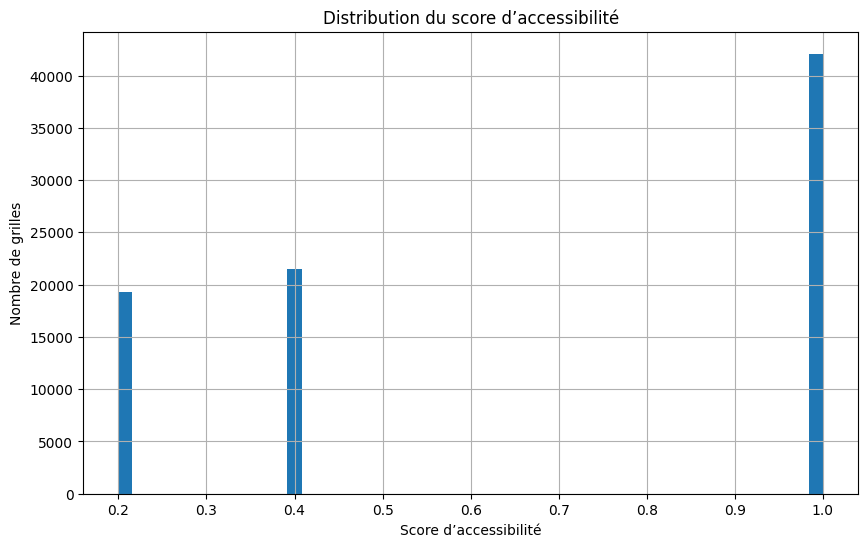

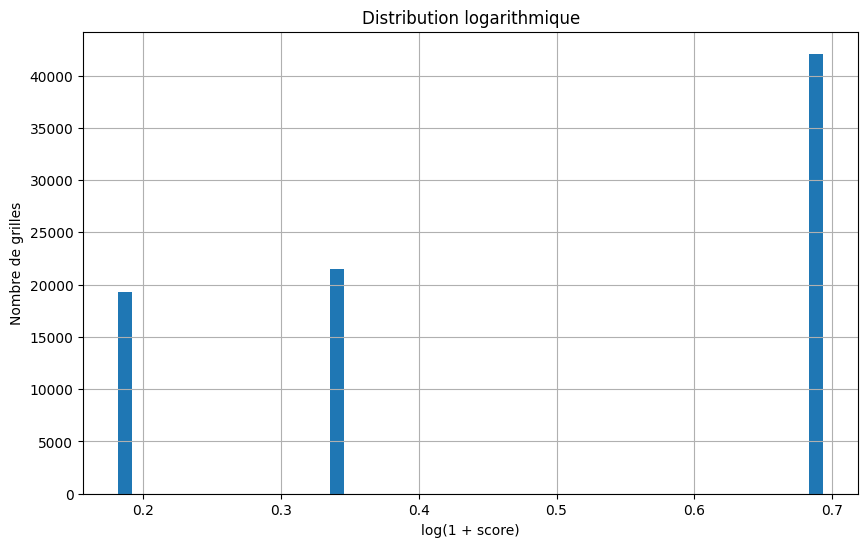

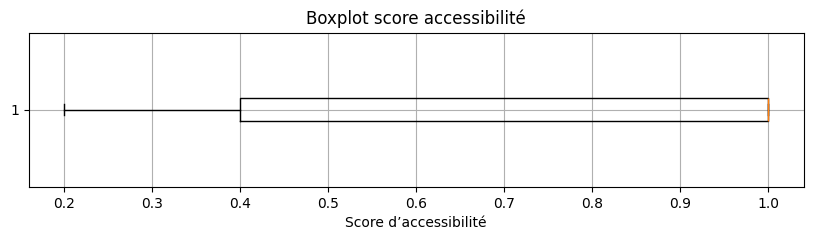

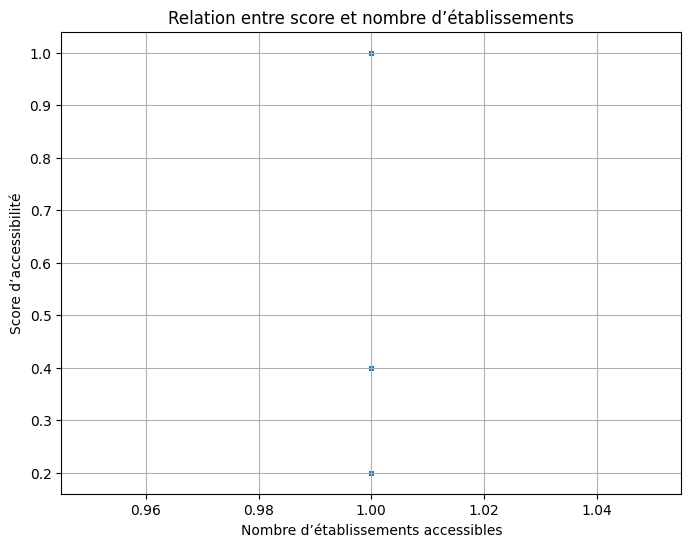


METHODOLOGIE

Analyse exploratoire réalisée
avant classification.

Méthodes utilisées :

- statistiques descriptives
- quantiles
- histogrammes
- boxplot
- corrélation
- dispersion

Objectifs :

identifier :

- asymétrie
- concentration spatiale
- hypercentralité
- valeurs extrêmes
- influence du nombre
  d’établissements accessibles
- influence de la distance

La méthode de classification
sera choisie après analyse
de la distribution observée.



In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =========================================================
# (1) CHARGEMENT
# =========================================================
file_path = "/content/grille_finale_college.gpkg"

gdf = gpd.read_file(file_path)

print("\n==============================")
print("COUCHE : AUTRES ETUDES")
print("=============================")

print("Nombre de colonnes :", len(gdf.columns))
print("Colonnes :", list(gdf.columns))
print("CRS :", gdf.crs)

# =========================================================
# (2) VERIFICATION
# =========================================================
print("\n=============================")
print("APERÇU")
print("=============================")

print(
    gdf[
        [
            "idINSPIRE",
            "score_access",
            "nb_college_accessibles"
        ]
    ].head()
)

# =========================================================
# (3) STATISTIQUES GENERALES
# =========================================================
print("\n=============================")
print("STATISTIQUES GENERALES")
print("=============================")

stats = gdf["score_access"].describe()

print(stats)

# =========================================================
# (4) NB GRILLES AVEC / SANS ACCESSIBILITE
# =========================================================
print("\n=============================")
print("GRILLES AVEC / SANS ACCESSIBILITE")
print("=============================")

nb_zero = (
    gdf["score_access"] == 0
).sum()

nb_nonzero = (
    gdf["score_access"] > 0
).sum()

print("Sans accessibilité :", nb_zero)
print("Avec accessibilité :", nb_nonzero)

# =========================================================
# (5) STATISTIQUES SANS ZERO
# =========================================================
gdf_nonzero = gdf[
    gdf["score_access"] > 0
].copy()

print("\n=============================")
print("STATISTIQUES SANS ZERO")
print("=============================")

stats_nonzero = (
    gdf_nonzero["score_access"]
    .describe()
)

print(stats_nonzero)

# =========================================================
# (6) QUANTILES
# =========================================================
print("\n=============================")
print("QUANTILES SANS ZERO")
print("=============================")

quantiles = (
    gdf_nonzero["score_access"]
    .quantile([
        0,
        0.05,
        0.10,
        0.20,
        0.40,
        0.60,
        0.80,
        0.90,
        0.95,
        0.99,
        1
    ])
)

print(quantiles)

# =========================================================
# (7) TOP SCORES
# =========================================================
print("\n=============================")
print("TOP 20 SCORES")
print("=============================")

print(
    gdf_nonzero["score_access"]
    .sort_values(ascending=False)
    .head(20)
)

# =========================================================
# (8) NB ETABLISSEMENTS ACCESSIBLES
# =========================================================
print("\n=============================")
print("NB ETABLISSEMENTS ACCESSIBLES")
print("=============================")

print(
    gdf_nonzero[
        "nb_college_accessibles"
    ]
    .value_counts()
    .sort_index()
)

# =========================================================
# (9) CORRELATION
# =========================================================
print("\n=============================")
print("CORRELATION")
print("=============================")

correlation = gdf_nonzero[
    [
        "score_access",
        "nb_college_accessibles"
    ]
].corr()

print(correlation)

# =========================================================
# (10) REPARTITION PAR DISTANCE
# =========================================================
print("\n=============================")
print("REPARTITION PAR DISTANCE")
print("=============================")

dist_cols = [
    "dist_1000",
    "dist_2000",
    "dist_3000",
    "dist_4000",
    "dist_5000"
]

for c in dist_cols:

    total = (
        gdf_nonzero[c]
        .sum()
    )

    print(c, ":", int(total))

# =========================================================
# (11) HISTOGRAMME
# =========================================================
plt.figure(figsize=(10,6))

plt.hist(
    gdf_nonzero["score_access"],
    bins=50
)

plt.xlabel("Score d’accessibilité")
plt.ylabel("Nombre de grilles")

plt.title(
    "Distribution du score d’accessibilité"
)

plt.grid()

plt.show()

# =========================================================
# (12) HISTOGRAMME LOG
# =========================================================
plt.figure(figsize=(10,6))

plt.hist(
    np.log1p(
        gdf_nonzero["score_access"]
    ),
    bins=50
)

plt.xlabel("log(1 + score)")
plt.ylabel("Nombre de grilles")

plt.title(
    "Distribution logarithmique"
)

plt.grid()

plt.show()

# =========================================================
# (13) BOXPLOT
# =========================================================
plt.figure(figsize=(10,2))

plt.boxplot(
    gdf_nonzero["score_access"],
    vert=False
)

plt.xlabel("Score d’accessibilité")

plt.title(
    "Boxplot score accessibilité"
)

plt.grid()

plt.show()

# =========================================================
# (14) DISPERSION
# =========================================================
plt.figure(figsize=(8,6))

plt.scatter(
    gdf_nonzero[
        "nb_college_accessibles"
    ],
    gdf_nonzero["score_access"],
    s=5
)

plt.xlabel(
    "Nombre d’établissements accessibles"
)

plt.ylabel(
    "Score d’accessibilité"
)

plt.title(
    "Relation entre score et nombre d’établissements"
)

plt.grid()

plt.show()



# **b Autres études**

## grille finale

In [ ]:
import geopandas as gpd
import pandas as pd

# =========================================================
# (1) CHARGEMENT ISOCHRONES
# =========================================================
iso_file = (
    "/content/"
    "isodistance_ors_autres_etude_1_5_km.gpkg"
)

gdf_iso = gpd.read_file(iso_file)

print("\n==============================")
print("ISOCHRONES AUTRES ETUDES")
print("==============================")

print("Colonnes :", list(gdf_iso.columns))
print("CRS :", gdf_iso.crs)

# =========================================================
# (2) CHARGEMENT GRILLE
# =========================================================
grid_file = (
    "/content/"
    "grille_alsace_sans_massifs.gpkg"
)

gdf_grid = gpd.read_file(grid_file)

print("\n==============================")
print("GRILLE")
print("==============================")

print("Colonnes :", list(gdf_grid.columns))
print("CRS :", gdf_grid.crs)

# =========================================================
# (3) MEME CRS
# =========================================================
if gdf_iso.crs != gdf_grid.crs:

    gdf_iso = gdf_iso.to_crs(
        gdf_grid.crs
    )

# =========================================================
# (4) INTERSECTION
# =========================================================
print("\n==============================")
print("INTERSECTION")
print("==============================")

gdf = gpd.overlay(
    gdf_grid,
    gdf_iso,
    how="intersection"
)

print("Nb intersections :", len(gdf))

# =========================================================
# (5) SURFACE INTERSECTION
# =========================================================
gdf["area"] = gdf.geometry.area

# =========================================================
# (6) APERCU
# =========================================================
print("\n==============================")
print("APERÇU")
print("==============================")

print(
    gdf[
        [
            "idINSPIRE",
            "nom",
            "AA_METERS",
            "area"
        ]
    ].head()
)

# =========================================================
# (7) AGRÉGATION
# =========================================================
grouped = (
    gdf.groupby(
        [
            "idINSPIRE",
            "nom",
            "AA_METERS"
        ],
        as_index=False
    )["area"]
    .sum()
)

print("\n==============================")
print("TABLE AGRÉGÉE")
print("==============================")

print(grouped.head())

# =========================================================
# (8) SURFACE TOTALE
# PAR GRILLE + ETABLISSEMENT
# =========================================================
sum_total = (
    grouped.groupby(
        [
            "idINSPIRE",
            "nom"
        ],
        as_index=False
    )["area"]
    .sum()
    .rename(
        columns={
            "area": "sum_area"
        }
    )
)

# =========================================================
# (9) VALIDATION
# =========================================================
THRESHOLD = 20000

sum_total["valid"] = (
    sum_total["sum_area"]
    > THRESHOLD
)

valid_pairs = (
    sum_total[
        sum_total["valid"]
    ][
        [
            "idINSPIRE",
            "nom"
        ]
    ]
)

print("\n==============================")
print("NB COUPLES VALIDES")
print("==============================")

print(len(valid_pairs))

# =========================================================
# (10) GARDER VALIDES
# =========================================================
grouped_valid = grouped.merge(
    valid_pairs,
    on=[
        "idINSPIRE",
        "nom"
    ],
    how="inner"
)

# =========================================================
# (11) DISTANCE MINIMALE
# =========================================================
minimal = (
    grouped_valid.groupby(
        [
            "idINSPIRE",
            "nom"
        ],
        as_index=False
    )["AA_METERS"]
    .min()
)

print("\n==============================")
print("DISTANCE MINIMALE")
print("==============================")

print(minimal.head())

# =========================================================
# (12) EXPORT CONTROLE
# =========================================================
minimal.to_csv(
    "/content/distance_minimale_autres_etudes.csv",
    index=False
)

# =========================================================
# (13) TABLEAU CROISÉ
# =========================================================
pivot = pd.pivot_table(
    minimal,
    index="idINSPIRE",
    columns="AA_METERS",
    values="nom",
    aggfunc="count",
    fill_value=0
)

# =========================================================
# (14) RENOMMER
# =========================================================
pivot = pivot.rename(
    columns={
        1000: "dist_1000",
        2000: "dist_2000",
        3000: "dist_3000",
        4000: "dist_4000",
        5000: "dist_5000"
    }
)

pivot = pivot.reset_index()

# =========================================================
# (15) COLONNES MANQUANTES
# =========================================================
wanted = [
    "dist_1000",
    "dist_2000",
    "dist_3000",
    "dist_4000",
    "dist_5000"
]

for c in wanted:

    if c not in pivot.columns:

        pivot[c] = 0

pivot = pivot[
    ["idINSPIRE"] + wanted
]

# =========================================================
# (16) SCORE
# =========================================================
pivot["score_access"] = (
      pivot["dist_1000"] * 1
    + pivot["dist_2000"] * 1
    + pivot["dist_3000"] * 1
    + pivot["dist_4000"] * 0.4
    + pivot["dist_5000"] * 0.2
)

# =========================================================
# (17) NB ETUDES ACCESSIBLES
# =========================================================
pivot["nb_etudes_accessibles"] = (
      pivot["dist_1000"]
    + pivot["dist_2000"]
    + pivot["dist_3000"]
    + pivot["dist_4000"]
    + pivot["dist_5000"]
)

print("\n==============================")
print("TABLEAU FINAL")
print("==============================")

print(pivot.head())

# =========================================================
# (18) JOINTURE FINALE
# =========================================================
gdf_grid["idINSPIRE"] = (
    gdf_grid["idINSPIRE"]
    .astype(str)
)

pivot["idINSPIRE"] = (
    pivot["idINSPIRE"]
    .astype(str)
)

gdf_final = gdf_grid.merge(
    pivot,
    on="idINSPIRE",
    how="left"
)

# =========================================================
# (19) NULL -> 0
# =========================================================
for c in wanted:

    gdf_final[c] = (
        gdf_final[c]
        .fillna(0)
    )

gdf_final["score_access"] = (
    gdf_final["score_access"]
    .fillna(0)
)

gdf_final["nb_etudes_accessibles"] = (
    gdf_final["nb_etudes_accessibles"]
    .fillna(0)
)

# =========================================================
# (20) EXPORT
# =========================================================
output = (
    "/content/"
    "grille_finale_autres_etudes.gpkg"
)

gdf_final.to_file(
    output,
    driver="GPKG"
)

print("\n==============================")
print("EXPORT FINAL")
print("==============================")

print(output)

print("\nNB GRILLES :", len(gdf_final))

print(
    gdf_final[
        [
            "idINSPIRE",
            "score_access",
            "nb_etudes_accessibles"
        ]
    ].head()
)


ISOCHRONES AUTRES ETUDES
Colonnes : ['nom', 'AA_METERS', 'AA_MODE', 'geometry']
CRS : EPSG:4326

GRILLE
Colonnes : ['idINSPIRE', 'geometry']
CRS : EPSG:3948

INTERSECTION
Nb intersections : 185597

APERÇU
                        idINSPIRE                             nom  AA_METERS  \
0  CRS3035RES200mN2746800E4092600  Lycée professionnel Joseph Vog       5000   
1  CRS3035RES200mN2746600E4092600  Lycée professionnel Joseph Vog       5000   
2  CRS3035RES200mN2746400E4092600  Lycée professionnel Joseph Vog       5000   
3  CRS3035RES200mN2746200E4092600  Lycée professionnel Joseph Vog       5000   
4  CRS3035RES200mN2746000E4092600  Lycée professionnel Joseph Vog       5000   

           area  
0    659.200707  
1  20832.077503  
2  39641.478917  
3  39993.721655  
4  39993.731016  

TABLE AGRÉGÉE
                        idINSPIRE                             nom  AA_METERS  \
0  CRS3035RES200mN2717600E4134000  Section d'enseignement profess       5000   
1  CRS3035RES200mN2717800E4133

## statistique


COUCHE : AUTRES ETUDES
Nombre de colonnes : 9
Colonnes : ['idINSPIRE', 'dist_1000', 'dist_2000', 'dist_3000', 'dist_4000', 'dist_5000', 'score_access', 'nb_etudes_accessibles', 'geometry']
CRS : EPSG:3948

APERÇU
                        idINSPIRE  score_access  nb_etudes_accessibles
0  CRS3035RES200mN2748800E4088000           0.0                    0.0
1  CRS3035RES200mN2748600E4088000           0.0                    0.0
2  CRS3035RES200mN2748400E4088000           0.0                    0.0
3  CRS3035RES200mN2748200E4088000           0.0                    0.0
4  CRS3035RES200mN2749200E4088200           0.0                    0.0

STATISTIQUES GENERALES
count    182455.000000
mean          0.242995
std           0.614938
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           6.800000
Name: score_access, dtype: float64

GRILLES AVEC / SANS ACCESSIBILITE
Sans accessibilité : 137574
Avec accessibilité : 44881

STATISTIQUES SANS ZERO
cou

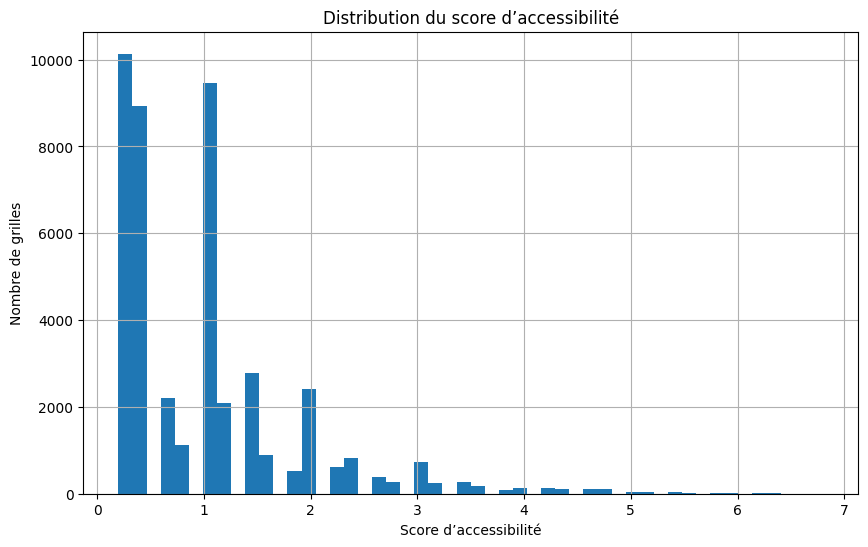

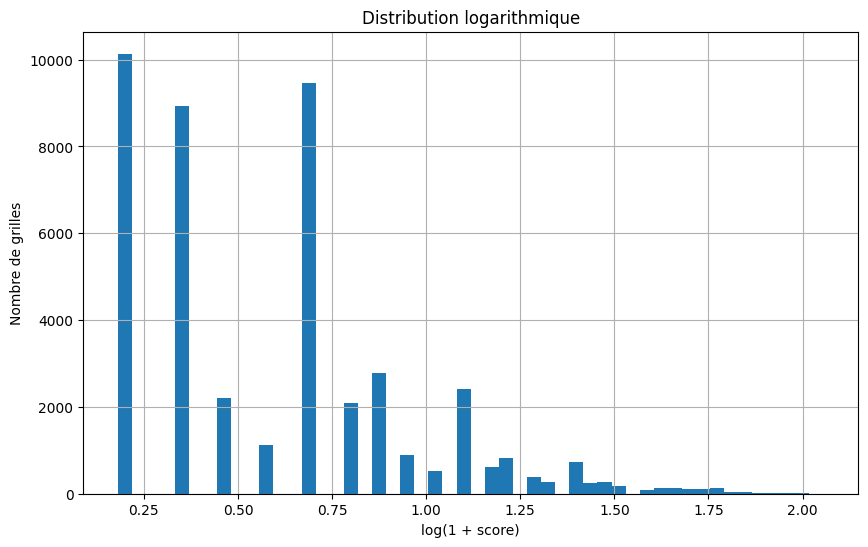

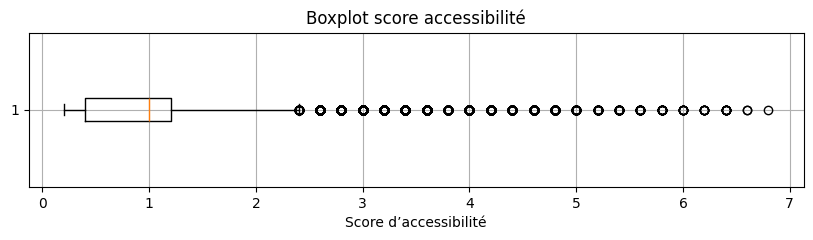

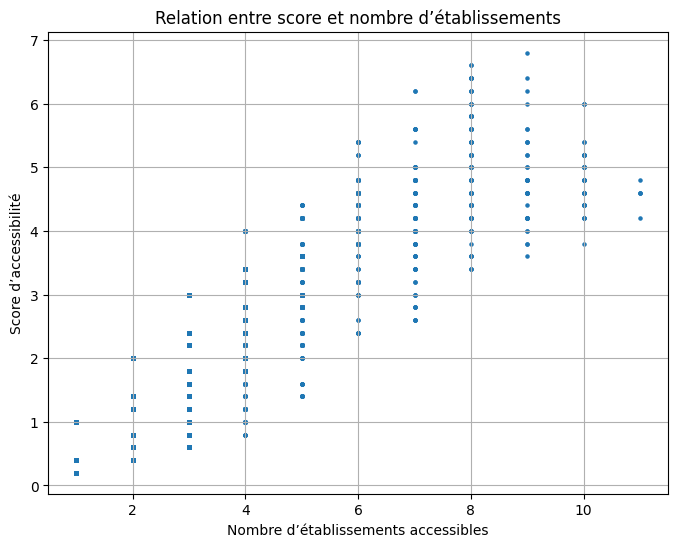


METHODOLOGIE

Analyse exploratoire réalisée
avant classification.

Méthodes utilisées :

- statistiques descriptives
- quantiles
- histogrammes
- boxplot
- corrélation
- dispersion

Objectifs :

identifier :

- asymétrie
- concentration spatiale
- hypercentralité
- valeurs extrêmes
- influence du nombre
  d’établissements accessibles
- influence de la distance

La méthode de classification
sera choisie après analyse
de la distribution observée.



In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =========================================================
# (1) CHARGEMENT
# =========================================================
file_path = "/content/grille_finale_autres_etudes.gpkg"

gdf = gpd.read_file(file_path)

print("\n==============================")
print("COUCHE : AUTRES ETUDES")
print("=============================")

print("Nombre de colonnes :", len(gdf.columns))
print("Colonnes :", list(gdf.columns))
print("CRS :", gdf.crs)

# =========================================================
# (2) VERIFICATION
# =========================================================
print("\n=============================")
print("APERÇU")
print("=============================")

print(
    gdf[
        [
            "idINSPIRE",
            "score_access",
            "nb_etudes_accessibles"
        ]
    ].head()
)

# =========================================================
# (3) STATISTIQUES GENERALES
# =========================================================
print("\n=============================")
print("STATISTIQUES GENERALES")
print("=============================")

stats = gdf["score_access"].describe()

print(stats)

# =========================================================
# (4) NB GRILLES AVEC / SANS ACCESSIBILITE
# =========================================================
print("\n=============================")
print("GRILLES AVEC / SANS ACCESSIBILITE")
print("=============================")

nb_zero = (
    gdf["score_access"] == 0
).sum()

nb_nonzero = (
    gdf["score_access"] > 0
).sum()

print("Sans accessibilité :", nb_zero)
print("Avec accessibilité :", nb_nonzero)

# =========================================================
# (5) STATISTIQUES SANS ZERO
# =========================================================
gdf_nonzero = gdf[
    gdf["score_access"] > 0
].copy()

print("\n=============================")
print("STATISTIQUES SANS ZERO")
print("=============================")

stats_nonzero = (
    gdf_nonzero["score_access"]
    .describe()
)

print(stats_nonzero)

# =========================================================
# (6) QUANTILES
# =========================================================
print("\n=============================")
print("QUANTILES SANS ZERO")
print("=============================")

quantiles = (
    gdf_nonzero["score_access"]
    .quantile([
        0,
        0.05,
        0.10,
        0.20,
        0.40,
        0.60,
        0.80,
        0.90,
        0.95,
        0.99,
        1
    ])
)

print(quantiles)

# =========================================================
# (7) TOP SCORES
# =========================================================
print("\n=============================")
print("TOP 20 SCORES")
print("=============================")

print(
    gdf_nonzero["score_access"]
    .sort_values(ascending=False)
    .head(20)
)

# =========================================================
# (8) NB ETABLISSEMENTS ACCESSIBLES
# =========================================================
print("\n=============================")
print("NB ETABLISSEMENTS ACCESSIBLES")
print("=============================")

print(
    gdf_nonzero[
        "nb_etudes_accessibles"
    ]
    .value_counts()
    .sort_index()
)

# =========================================================
# (9) CORRELATION
# =========================================================
print("\n=============================")
print("CORRELATION")
print("=============================")

correlation = gdf_nonzero[
    [
        "score_access",
        "nb_etudes_accessibles"
    ]
].corr()

print(correlation)

# =========================================================
# (10) REPARTITION PAR DISTANCE
# =========================================================
print("\n=============================")
print("REPARTITION PAR DISTANCE")
print("=============================")

dist_cols = [
    "dist_1000",
    "dist_2000",
    "dist_3000",
    "dist_4000",
    "dist_5000"
]

for c in dist_cols:

    total = (
        gdf_nonzero[c]
        .sum()
    )

    print(c, ":", int(total))

# =========================================================
# (11) HISTOGRAMME
# =========================================================
plt.figure(figsize=(10,6))

plt.hist(
    gdf_nonzero["score_access"],
    bins=50
)

plt.xlabel("Score d’accessibilité")
plt.ylabel("Nombre de grilles")

plt.title(
    "Distribution du score d’accessibilité"
)

plt.grid()

plt.show()

# =========================================================
# (12) HISTOGRAMME LOG
# =========================================================
plt.figure(figsize=(10,6))

plt.hist(
    np.log1p(
        gdf_nonzero["score_access"]
    ),
    bins=50
)

plt.xlabel("log(1 + score)")
plt.ylabel("Nombre de grilles")

plt.title(
    "Distribution logarithmique"
)

plt.grid()

plt.show()

# =========================================================
# (13) BOXPLOT
# =========================================================
plt.figure(figsize=(10,2))

plt.boxplot(
    gdf_nonzero["score_access"],
    vert=False
)

plt.xlabel("Score d’accessibilité")

plt.title(
    "Boxplot score accessibilité"
)

plt.grid()

plt.show()

# =========================================================
# (14) DISPERSION
# =========================================================
plt.figure(figsize=(8,6))

plt.scatter(
    gdf_nonzero[
        "nb_etudes_accessibles"
    ],
    gdf_nonzero["score_access"],
    s=5
)

plt.xlabel(
    "Nombre d’établissements accessibles"
)

plt.ylabel(
    "Score d’accessibilité"
)

plt.title(
    "Relation entre score et nombre d’établissements"
)

plt.grid()

plt.show()

# =========================================================
# (15) METHODOLOGIE
# =========================================================
print("\n=============================")
print("METHODOLOGIE")
print("=============================")

print("""
Analyse exploratoire réalisée
avant classification.

Méthodes utilisées :

- statistiques descriptives
- quantiles
- histogrammes
- boxplot
- corrélation
- dispersion

Objectifs :

identifier :

- asymétrie
- concentration spatiale
- hypercentralité
- valeurs extrêmes
- influence du nombre
  d’établissements accessibles
- influence de la distance

La méthode de classification
sera choisie après analyse
de la distribution observée.
""")

# **c Gares**

## grille finale

In [ ]:
import geopandas as gpd
import pandas as pd

# =========================================================
# (1) CHARGEMENT ISOCHRONES GARES
# =========================================================

iso_file = (
    "/content/"
    "isodistance_ors_gare_1_5_km.gpkg"
)

gdf_iso = gpd.read_file(iso_file)

print("\n==============================")
print("ISOCHRONES GARES")
print("==============================")
print(gdf_iso.columns)
print(gdf_iso.crs)

# =========================================================
# (2) CHARGEMENT GRILLE
# =========================================================

grid_file = (
    "/content/"
    "grille_alsace_sans_massifs.gpkg"
)

gdf_grid = gpd.read_file(grid_file)

print("\n==============================")
print("GRILLE")
print("==============================")
print(gdf_grid.columns)
print(gdf_grid.crs)

# =========================================================
# (3) MEME CRS
# =========================================================

if gdf_iso.crs != gdf_grid.crs:
    gdf_iso = gdf_iso.to_crs(gdf_grid.crs)

# =========================================================
# (4) INTERSECTION
# =========================================================

print("\n==============================")
print("INTERSECTION")
print("==============================")

gdf = gpd.overlay(
    gdf_grid,
    gdf_iso,
    how="intersection"
)

print("Nb intersections :", len(gdf))

# =========================================================
# (5) SURFACE D'INTERSECTION
# =========================================================

gdf["area"] = gdf.geometry.area

print("\n==============================")
print("APERÇU")
print("==============================")

print(
    gdf[
        [
            "idINSPIRE",
            "Nom_Gare",
            "AA_METERS",
            "classe_freq",
            "area"
        ]
    ].head()
)

# =========================================================
# (6) AGREGER LES SURFACES
# (une ligne par maille × gare × distance)
# =========================================================

grouped = (
    gdf
    .groupby(
        [
            "idINSPIRE",
            "Nom_Gare",
            "classe_freq",
            "AA_METERS"
        ],
        as_index=False
    )["area"]
    .sum()
)

print(grouped.head())

# =========================================================
# (7) SURFACE TOTALE PAR MAILLE × GARE
# =========================================================

sum_total = (
    grouped
    .groupby(
        [
            "idINSPIRE",
            "Nom_Gare",
            "classe_freq"
        ],
        as_index=False
    )["area"]
    .sum()
    .rename(
        columns={
            "area": "sum_area"
        }
    )
)

# =========================================================
# (8) FILTRE SURFACE
# =========================================================

THRESHOLD = 20000

sum_total = sum_total[
    sum_total["sum_area"] >= THRESHOLD
].copy()

print("\nNb couples conservés :", len(sum_total))

# =========================================================
# (9) CONSERVER UNIQUEMENT LES GARES VALIDES
# =========================================================

grouped_valid = grouped.merge(
    sum_total[
        [
            "idINSPIRE",
            "Nom_Gare",
            "classe_freq"
        ]
    ],
    on=[
        "idINSPIRE",
        "Nom_Gare",
        "classe_freq"
    ],
    how="inner"
)

print("\nNb intersections conservées :", len(grouped_valid))

# =========================================================
# (10) DISTANCE MINIMALE PAR MAILLE × GARE
# =========================================================

minimal = (
    grouped_valid
    .groupby(
        [
            "idINSPIRE",
            "Nom_Gare",
            "classe_freq"
        ],
        as_index=False
    )["AA_METERS"]
    .min()
)

print("\n==============================")
print("DISTANCE MINIMALE")
print("==============================")

print(minimal.head())

# =========================================================
# (11) EXPORT DE CONTRÔLE
# =========================================================

minimal.to_csv(
    "/content/distance_minimale_gares.csv",
    index=False
)

# =========================================================
# (12) POIDS SELON LA DISTANCE
# =========================================================

distance_weights = {
    1000: 1.0,
    2000: 1.0,
    3000: 1.0,
    4000: 0.4,
    5000: 0.2
}

minimal["distance_weight"] = (
    minimal["AA_METERS"]
    .map(distance_weights)
    .fillna(0)
)

# =========================================================
# (13) SCORE DE CHAQUE GARE
# = classe_freq × poids_distance
# =========================================================

minimal["gare_score"] = (
    minimal["classe_freq"]
    * minimal["distance_weight"]
)

print("\n==============================")
print("APERÇU SCORE GARE")
print("==============================")

print(
    minimal[
        [
            "idINSPIRE",
            "Nom_Gare",
            "AA_METERS",
            "classe_freq",
            "distance_weight",
            "gare_score"
        ]
    ].head(10)
)

# =========================================================
# (14) TABLEAU CROISÉ DES DISTANCES
# =========================================================

pivot_dist = pd.pivot_table(
    minimal,
    index="idINSPIRE",
    columns="AA_METERS",
    values="Nom_Gare",
    aggfunc="count",
    fill_value=0
)

pivot_dist = pivot_dist.rename(
    columns={
        1000: "dist_1000",
        2000: "dist_2000",
        3000: "dist_3000",
        4000: "dist_4000",
        5000: "dist_5000"
    }
)

pivot_dist = pivot_dist.reset_index()

wanted = [
    "dist_1000",
    "dist_2000",
    "dist_3000",
    "dist_4000",
    "dist_5000"
]

for c in wanted:
    if c not in pivot_dist.columns:
        pivot_dist[c] = 0

pivot_dist = pivot_dist[
    ["idINSPIRE"] + wanted
]

# =========================================================
# (15) SCORE GLOBAL DES GARES
# (somme des classe_freq × poids_distance)
# =========================================================

score_grid = (
    minimal
    .groupby(
        "idINSPIRE",
        as_index=False
    )["gare_score"]
    .sum()
    .rename(
        columns={
            "gare_score": "score_access"
        }
    )
)

# =========================================================
# (16) NOMBRE DE GARES ACCESSIBLES
# =========================================================

nb_grid = (
    minimal
    .groupby(
        "idINSPIRE",
        as_index=False
    )
    .size()
    .rename(
        columns={
            "size": "nb_accessibles"
        }
    )
)

# =========================================================
# (17) TABLE FINALE
# =========================================================

pivot = (
    pivot_dist
    .merge(
        score_grid,
        on="idINSPIRE",
        how="left"
    )
    .merge(
        nb_grid,
        on="idINSPIRE",
        how="left"
    )
)

pivot["score_access"] = (
    pivot["score_access"]
    .fillna(0)
)

pivot["nb_accessibles"] = (
    pivot["nb_accessibles"]
    .fillna(0)
    .astype(int)
)

print("\n==============================")
print("TABLEAU FINAL")
print("==============================")

print(pivot.head())

print("\nStatistiques score_access :")
print(pivot["score_access"].describe())



# =========================================================
# (18) PREPARATION DES IDENTIFIANTS
# =========================================================

gdf_grid["idINSPIRE"] = (
    gdf_grid["idINSPIRE"]
    .astype(str)
)

pivot["idINSPIRE"] = (
    pivot["idINSPIRE"]
    .astype(str)
)

# =========================================================
# (19) JOINTURE AVEC LA GRILLE
# =========================================================

gdf_final = gdf_grid.merge(
    pivot,
    on="idINSPIRE",
    how="left"
)

# =========================================================
# (20) REMPLACER LES VALEURS MANQUANTES
# =========================================================

wanted = [
    "dist_1000",
    "dist_2000",
    "dist_3000",
    "dist_4000",
    "dist_5000"
]

for c in wanted:
    gdf_final[c] = (
        gdf_final[c]
        .fillna(0)
        .astype(int)
    )

gdf_final["score_access"] = (
    gdf_final["score_access"]
    .fillna(0)
)

gdf_final["nb_accessibles"] = (
    gdf_final["nb_accessibles"]
    .fillna(0)
    .astype(int)
)

# =========================================================
# (21) EXPORT GPKG
# =========================================================

output = (
    "/content/"
    "grille_finale_gare.gpkg"
)

gdf_final.to_file(
    output,
    driver="GPKG"
)

# =========================================================
# (22) EXPORT CSV (OPTIONNEL)
# =========================================================

pivot.to_csv(
    "/content/table_accessibilite_gares.csv",
    index=False
)

# =========================================================
# (23) INFORMATIONS
# =========================================================

print("\n==============================")
print("EXPORT FINAL")
print("==============================")

print("Fichier GPKG :", output)
print("Nombre de mailles :", len(gdf_final))

print("\nColonnes :")
print(list(gdf_final.columns))

print("\nAperçu :")
print(
    gdf_final[
        [
            "idINSPIRE",
            "dist_1000",
            "dist_2000",
            "dist_3000",
            "dist_4000",
            "dist_5000",
            "nb_accessibles",
            "score_access"
        ]
    ].head()
)

print("\n==============================")
print("STATISTIQUES")
print("==============================")

print(gdf_final["score_access"].describe())

print("\nNombre de mailles avec au moins une gare accessible :")
print((gdf_final["nb_accessibles"] > 0).sum())

print("\nNombre total de mailles :")
print(len(gdf_final))

DataSourceError: /content/isodistance_ors_gare_1_5_km.gpkg: No such file or directory

## statistique


COUCHE : AUTRES ETUDES
Nombre de colonnes : 9
Colonnes : ['idINSPIRE', 'dist_1000', 'dist_2000', 'dist_3000', 'dist_4000', 'dist_5000', 'score_access', 'nb_accessibles', 'geometry']
CRS : EPSG:3948

APERÇU
                        idINSPIRE  score_access  nb_accessibles
0  CRS3035RES200mN2748800E4088000           0.0               0
1  CRS3035RES200mN2748600E4088000           0.0               0
2  CRS3035RES200mN2748400E4088000           0.0               0
3  CRS3035RES200mN2748200E4088000           0.0               0
4  CRS3035RES200mN2749200E4088200           0.0               0

STATISTIQUES GENERALES
count    182455.000000
mean          0.764062
std           1.279411
min           0.000000
25%           0.000000
50%           0.000000
75%           1.200000
max           9.200000
Name: score_access, dtype: float64

GRILLES AVEC / SANS ACCESSIBILITE
Sans accessibilité : 98681
Avec accessibilité : 83774

STATISTIQUES SANS ZERO
count    83774.000000
mean         1.664084
std      

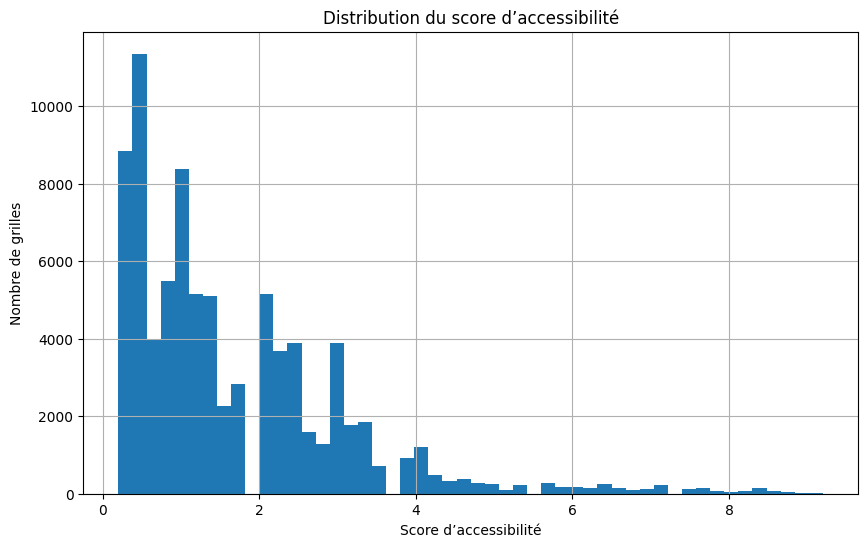

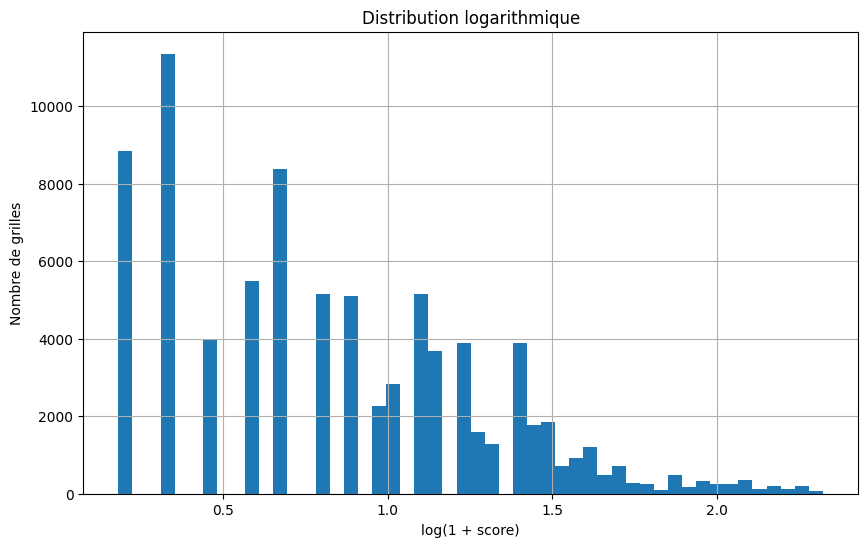

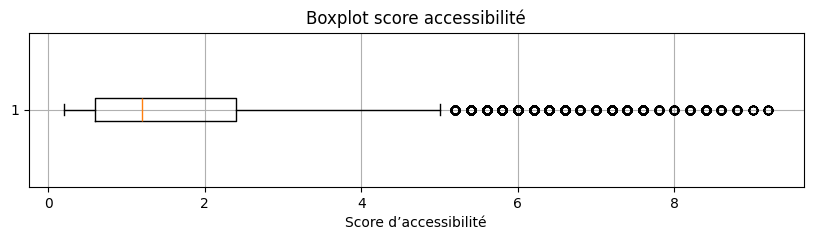

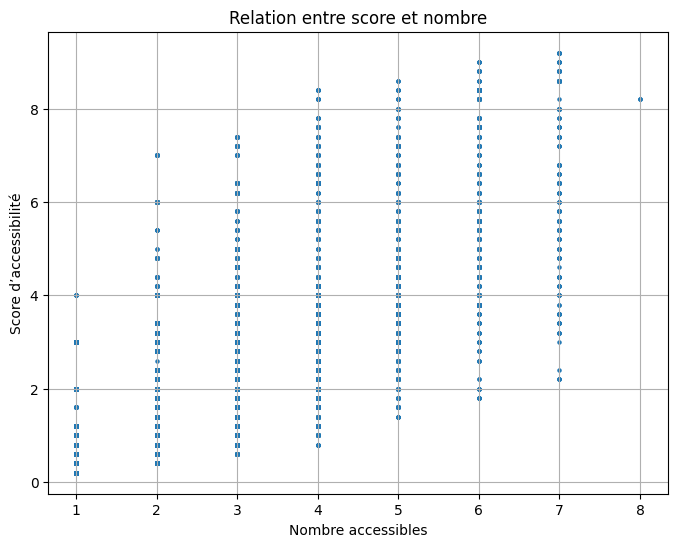


METHODOLOGIE

Analyse exploratoire réalisée
avant classification.

Méthodes utilisées :

- statistiques descriptives
- quantiles
- histogrammes
- boxplot
- corrélation
- dispersion

Objectifs :

identifier :

- asymétrie
- concentration spatiale
- hypercentralité
- valeurs extrêmes
- influence du nombre
  d’établissements accessibles
- influence de la distance

La méthode de classification
sera choisie après analyse
de la distribution observée.



In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =========================================================
# (1) CHARGEMENT
# =========================================================
file_path = "/content/grille_finale_gare.gpkg"

gdf = gpd.read_file(file_path)

print("\n==============================")
print("COUCHE : AUTRES ETUDES")
print("=============================")

print("Nombre de colonnes :", len(gdf.columns))
print("Colonnes :", list(gdf.columns))
print("CRS :", gdf.crs)

# =========================================================
# (2) VERIFICATION
# =========================================================
print("\n=============================")
print("APERÇU")
print("=============================")

print(
    gdf[
        [
            "idINSPIRE",
            "score_access",
            "nb_accessibles"
        ]
    ].head()
)

# =========================================================
# (3) STATISTIQUES GENERALES
# =========================================================
print("\n=============================")
print("STATISTIQUES GENERALES")
print("=============================")

stats = gdf["score_access"].describe()

print(stats)

# =========================================================
# (4) NB GRILLES AVEC / SANS ACCESSIBILITE
# =========================================================
print("\n=============================")
print("GRILLES AVEC / SANS ACCESSIBILITE")
print("=============================")

nb_zero = (
    gdf["score_access"] == 0
).sum()

nb_nonzero = (
    gdf["score_access"] > 0
).sum()

print("Sans accessibilité :", nb_zero)
print("Avec accessibilité :", nb_nonzero)

# =========================================================
# (5) STATISTIQUES SANS ZERO
# =========================================================
gdf_nonzero = gdf[
    gdf["score_access"] > 0
].copy()

print("\n=============================")
print("STATISTIQUES SANS ZERO")
print("=============================")

stats_nonzero = (
    gdf_nonzero["score_access"]
    .describe()
)

print(stats_nonzero)

# =========================================================
# (6) QUANTILES
# =========================================================
print("\n=============================")
print("QUANTILES SANS ZERO")
print("=============================")

quantiles = (
    gdf_nonzero["score_access"]
    .quantile([
        0,
        0.05,
        0.10,
        0.20,
        0.40,
        0.60,
        0.80,
        0.90,
        0.95,
        0.99,
        1
    ])
)

print(quantiles)

# =========================================================
# (7) TOP SCORES
# =========================================================
print("\n=============================")
print("TOP 20 SCORES")
print("=============================")

print(
    gdf_nonzero["score_access"]
    .sort_values(ascending=False)
    .head(20)
)

# =========================================================
# (8) NB ETABLISSEMENTS ACCESSIBLES
# =========================================================
print("\n=============================")
print("NB ETABLISSEMENTS ACCESSIBLES")
print("=============================")

print(
    gdf_nonzero[
        "nb_accessibles"
    ]
    .value_counts()
    .sort_index()
)

# =========================================================
# (9) CORRELATION
# =========================================================
print("\n=============================")
print("CORRELATION")
print("=============================")

correlation = gdf_nonzero[
    [
        "score_access",
        "nb_accessibles"
    ]
].corr()

print(correlation)

# =========================================================
# (10) REPARTITION PAR DISTANCE
# =========================================================
print("\n=============================")
print("REPARTITION PAR DISTANCE")
print("=============================")

dist_cols = [
    "dist_1000",
    "dist_2000",
    "dist_3000",
    "dist_4000",
    "dist_5000"
]

for c in dist_cols:

    total = (
        gdf_nonzero[c]
        .sum()
    )

    print(c, ":", int(total))

# =========================================================
# (11) HISTOGRAMME
# =========================================================
plt.figure(figsize=(10,6))

plt.hist(
    gdf_nonzero["score_access"],
    bins=50
)

plt.xlabel("Score d’accessibilité")
plt.ylabel("Nombre de grilles")

plt.title(
    "Distribution du score d’accessibilité"
)

plt.grid()

plt.show()

# =========================================================
# (12) HISTOGRAMME LOG
# =========================================================
plt.figure(figsize=(10,6))

plt.hist(
    np.log1p(
        gdf_nonzero["score_access"]
    ),
    bins=50
)

plt.xlabel("log(1 + score)")
plt.ylabel("Nombre de grilles")

plt.title(
    "Distribution logarithmique"
)

plt.grid()

plt.show()

# =========================================================
# (13) BOXPLOT
# =========================================================
plt.figure(figsize=(10,2))

plt.boxplot(
    gdf_nonzero["score_access"],
    vert=False
)

plt.xlabel("Score d’accessibilité")

plt.title(
    "Boxplot score accessibilité"
)

plt.grid()

plt.show()

# =========================================================
# (14) DISPERSION
# =========================================================
plt.figure(figsize=(8,6))

plt.scatter(
    gdf_nonzero[
        "nb_accessibles"
    ],
    gdf_nonzero["score_access"],
    s=5
)

plt.xlabel(
    "Nombre accessibles"
)

plt.ylabel(
    "Score d’accessibilité"
)

plt.title(
    "Relation entre score et nombre"
)

plt.grid()

plt.show()

# =========================================================
# (15) METHODOLOGIE
# =========================================================
print("\n=============================")
print("METHODOLOGIE")
print("=============================")

print("""
Analyse exploratoire réalisée
avant classification.

Méthodes utilisées :

- statistiques descriptives
- quantiles
- histogrammes
- boxplot
- corrélation
- dispersion

Objectifs :

identifier :

- asymétrie
- concentration spatiale
- hypercentralité
- valeurs extrêmes
- influence du nombre
  d’établissements accessibles
- influence de la distance

La méthode de classification
sera choisie après analyse
de la distribution observée.
""")

# **d Car TER Fluo**

## grille finale

In [ ]:
import geopandas as gpd
import pandas as pd

# =========================================================
# (1) CHARGEMENT ISOCHRONES
# =========================================================

iso_file = (
    "/content/"
    "isodistance_ors_cars_1_5_km.gpkg"
)

gdf_iso = gpd.read_file(iso_file)

print("\n==============================")
print("ISOCHRONES CARS TER")
print("==============================")

print("Colonnes :", list(gdf_iso.columns))
print("CRS :", gdf_iso.crs)

# =========================================================
# (2) SUPPRIMER NIVEAU 1
# =========================================================

gdf_iso = gdf_iso[
    gdf_iso["niveau"] >= 2
].copy()

print(
    "Arrêts conservés :",
    len(gdf_iso)
)

# =========================================================
# (3) CHARGEMENT GRILLE
# =========================================================

grid_file = (
    "/content/"
    "grille_alsace_sans_massifs.gpkg"
)

gdf_grid = gpd.read_file(grid_file)

print("\n==============================")
print("GRILLE")
print("==============================")

print("CRS :", gdf_grid.crs)

# =========================================================
# (4) MEME CRS
# =========================================================

if gdf_iso.crs != gdf_grid.crs:

    gdf_iso = gdf_iso.to_crs(
        gdf_grid.crs
    )

# =========================================================
# (5) INTERSECTION
# =========================================================

print("\n==============================")
print("INTERSECTION")
print("==============================")

gdf = gpd.overlay(
    gdf_grid,
    gdf_iso,
    how="intersection"
)

print(
    "Nb intersections :",
    len(gdf)
)

# =========================================================
# (6) SURFACE
# =========================================================

gdf["area"] = (
    gdf.geometry.area
)

# =========================================================
# (7) AGRÉGATION
# MAILLE + ARRET + DISTANCE
# =========================================================

grouped = (
    gdf.groupby(
        [
            "idINSPIRE",
            "name",
            "AA_METERS",
            "niveau"
        ],
        as_index=False
    )["area"]
    .sum()
)

# =========================================================
# (8) SURFACE TOTALE
# MAILLE + ARRET
# =========================================================

sum_total = (
    grouped.groupby(
        [
            "idINSPIRE",
            "name",
            "niveau"
        ],
        as_index=False
    )["area"]
    .sum()
    .rename(
        columns={
            "area":"sum_area"
        }
    )
)

# =========================================================
# (9) FILTRE SURFACE
# =========================================================

THRESHOLD = 20000

sum_total = sum_total[
    sum_total["sum_area"]
    >= THRESHOLD
].copy()

print(
    "Couples valides :",
    len(sum_total)
)

# =========================================================
# (10) REJOINDRE
# =========================================================

grouped_valid = grouped.merge(
    sum_total[
        [
            "idINSPIRE",
            "name",
            "niveau"
        ]
    ],
    on=[
        "idINSPIRE",
        "name",
        "niveau"
    ],
    how="inner"
)

# =========================================================
# (11) DISTANCE MINIMALE
# =========================================================

minimal = (
    grouped_valid.groupby(
        [
            "idINSPIRE",
            "name",
            "niveau"
        ],
        as_index=False
    )["AA_METERS"]
    .min()
)

# =========================================================
# (12) POIDS DISTANCE
# =========================================================

distance_weights = {
    1000:1.0,
    2000:1.0,
    3000:1.0,
    4000:0.4,
    5000:0.2
}

minimal["distance_weight"] = (
    minimal["AA_METERS"]
    .map(distance_weights)
)

# =========================================================
# (13) SCORE ARRET
# =========================================================

minimal["cars_score"] = (
    minimal["distance_weight"]
    *
    minimal["niveau"]
)

# =========================================================
# (14) EXPORT CONTROLE
# =========================================================

minimal.to_csv(
    "/content/cars_scores_detail.csv",
    index=False
)

# =========================================================
# (15) SCORE PAR MAILLE
# =========================================================

score_grid = (
    minimal.groupby(
        "idINSPIRE",
        as_index=False
    )
    .agg(
        score_access=(
            "cars_score",
            "sum"
        ),
        nb_accessibles=(
            "name",
            "nunique"
        )
    )
)

# =========================================================
# (16) TABLE DISTANCES
# =========================================================

pivot = pd.pivot_table(
    minimal,
    index="idINSPIRE",
    columns="AA_METERS",
    values="name",
    aggfunc="count",
    fill_value=0
)

pivot = pivot.rename(
    columns={
        1000:"dist_1000",
        2000:"dist_2000",
        3000:"dist_3000",
        4000:"dist_4000",
        5000:"dist_5000"
    }
)

pivot = pivot.reset_index()

wanted = [
    "dist_1000",
    "dist_2000",
    "dist_3000",
    "dist_4000",
    "dist_5000"
]

for c in wanted:

    if c not in pivot.columns:

        pivot[c] = 0

pivot = pivot[
    ["idINSPIRE"] + wanted
]

# =========================================================
# (17) FUSION
# =========================================================

pivot = pivot.merge(
    score_grid,
    on="idINSPIRE",
    how="left"
)

# =========================================================
# (18) JOINTURE FINALE
# =========================================================

gdf_grid["idINSPIRE"] = (
    gdf_grid["idINSPIRE"]
    .astype(str)
)

pivot["idINSPIRE"] = (
    pivot["idINSPIRE"]
    .astype(str)
)

gdf_final = gdf_grid.merge(
    pivot,
    on="idINSPIRE",
    how="left"
)

# =========================================================
# (19) NULL -> 0
# =========================================================

for c in wanted:

    gdf_final[c] = (
        gdf_final[c]
        .fillna(0)
    )

gdf_final["score_access"] = (
    gdf_final["score_access"]
    .fillna(0)
)

gdf_final["nb_accessibles"] = (
    gdf_final["nb_accessibles"]
    .fillna(0)
)

# =========================================================
# (20) EXPORT
# =========================================================

output = (
    "/content/"
    "grille_finale_cars_ter.gpkg"
)

gdf_final.to_file(
    output,
    driver="GPKG"
)

print("\n==============================")
print("EXPORT FINAL")
print("==============================")

print(output)

print(
    gdf_final[
        [
            "idINSPIRE",
            "score_access",
            "nb_accessibles"
        ]
    ]
    .head()
)


ISOCHRONES CARS TER
Colonnes : ['name', 'AA_METERS', 'niveau', 'geometry']
CRS : EPSG:4326
Arrêts conservés : 105

GRILLE
CRS : EPSG:3948

INTERSECTION
Nb intersections : 58642
Couples valides : 23794

EXPORT FINAL
/content/grille_finale_cars_ter.gpkg
                        idINSPIRE  score_access  nb_accessibles
0  CRS3035RES200mN2748800E4088000           0.0             0.0
1  CRS3035RES200mN2748600E4088000           0.0             0.0
2  CRS3035RES200mN2748400E4088000           0.0             0.0
3  CRS3035RES200mN2748200E4088000           0.0             0.0
4  CRS3035RES200mN2749200E4088200           0.0             0.0


## statistique


COUCHE : CARS TER
Nombre de colonnes : 9
Colonnes : ['idINSPIRE', 'dist_1000', 'dist_2000', 'dist_3000', 'dist_4000', 'dist_5000', 'score_access', 'nb_accessibles', 'geometry']
CRS : EPSG:3948

APERÇU
                        idINSPIRE  score_access  nb_accessibles
0  CRS3035RES200mN2748800E4088000           0.0             0.0
1  CRS3035RES200mN2748600E4088000           0.0             0.0
2  CRS3035RES200mN2748400E4088000           0.0             0.0
3  CRS3035RES200mN2748200E4088000           0.0             0.0
4  CRS3035RES200mN2749200E4088200           0.0             0.0

STATISTIQUES GENERALES
count    182455.000000
mean          0.211743
std           0.843752
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           9.000000
Name: score_access, dtype: float64

GRILLES AVEC / SANS ACCESSIBILITE
Sans accessibilité : 164239
Avec accessibilité : 18216

STATISTIQUES SANS ZERO
count    18216.000000
mean         2.120861
std          

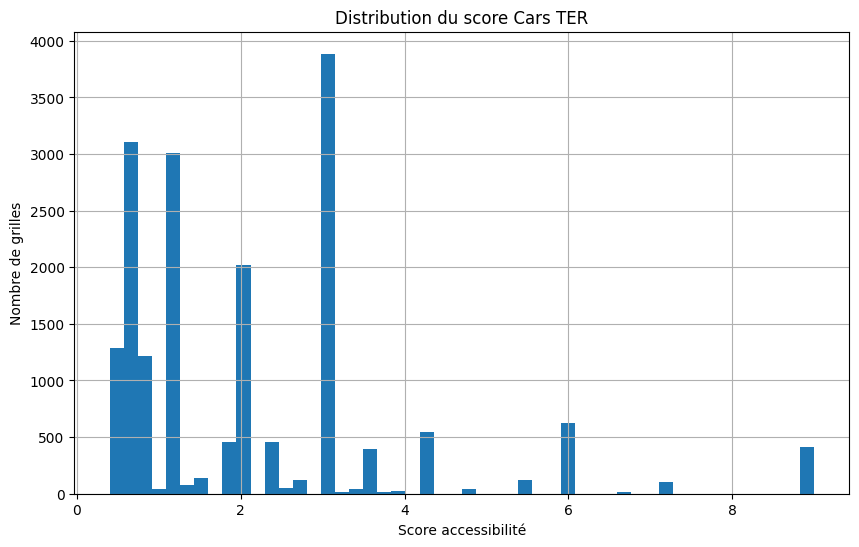

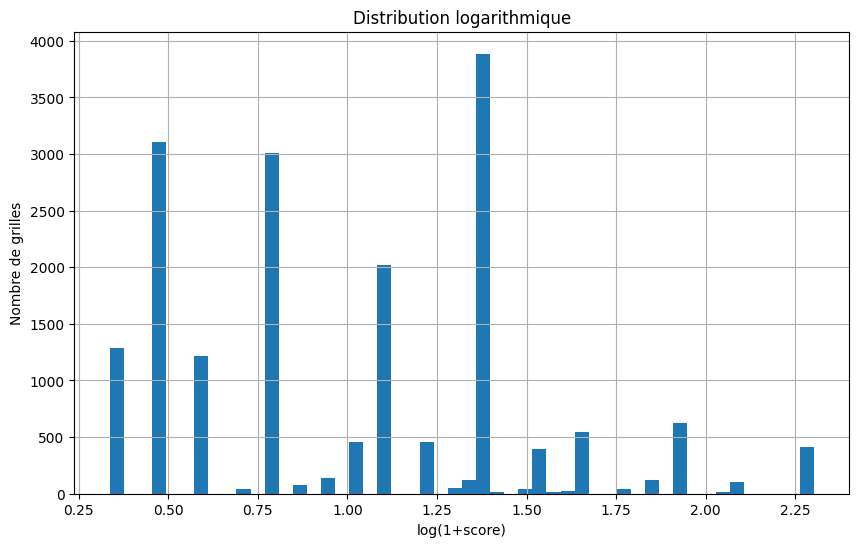

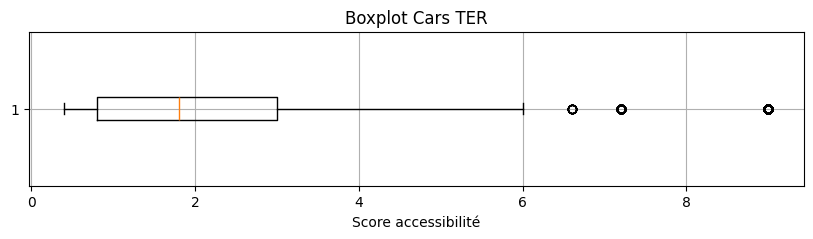

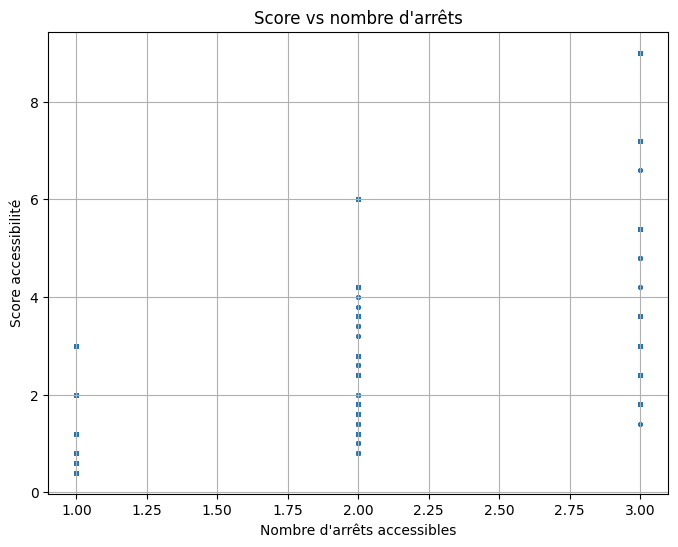

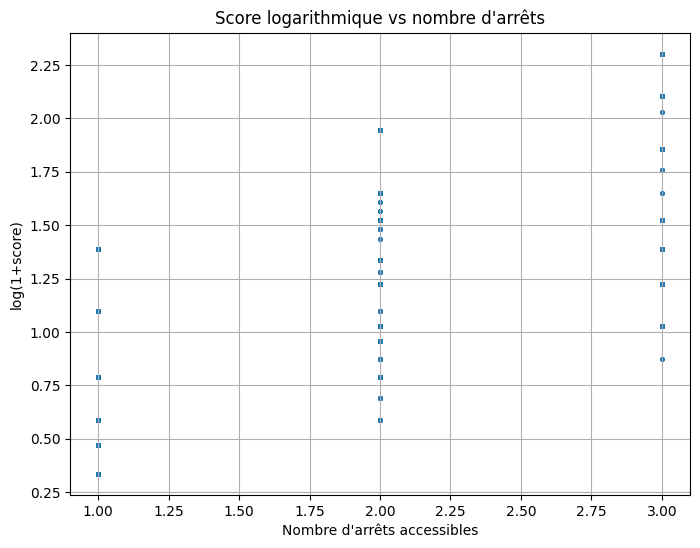


METHODOLOGIE


Analyse exploratoire réalisée
avant classification.

Méthodes utilisées :

- statistiques descriptives
- quantiles
- histogrammes
- boxplot
- corrélation
- dispersion

Objectifs :

identifier :

- asymétrie
- concentration spatiale
- hypercentralité
- valeurs extrêmes
- influence du nombre
  d'arrêts accessibles
- influence de la distance
- influence du niveau TER

La méthode de classification
sera choisie après analyse
de la distribution observée.




In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =========================================================
# (1) CHARGEMENT
# =========================================================

file_path = "/content/grille_finale_cars_ter.gpkg"

gdf = gpd.read_file(file_path)

print("\n==============================")
print("COUCHE : CARS TER")
print("=============================")

print("Nombre de colonnes :", len(gdf.columns))
print("Colonnes :", list(gdf.columns))
print("CRS :", gdf.crs)

# =========================================================
# (2) APERCU
# =========================================================

print("\n=============================")
print("APERÇU")
print("=============================")

print(
    gdf[
        [
            "idINSPIRE",
            "score_access",
            "nb_accessibles"
        ]
    ].head()
)

# =========================================================
# (3) STATISTIQUES GENERALES
# =========================================================

print("\n=============================")
print("STATISTIQUES GENERALES")
print("=============================")

print(
    gdf["score_access"]
    .describe()
)

# =========================================================
# (4) ACCESSIBILITE
# =========================================================

print("\n=============================")
print("GRILLES AVEC / SANS ACCESSIBILITE")
print("=============================")

nb_zero = (
    gdf["score_access"] == 0
).sum()

nb_nonzero = (
    gdf["score_access"] > 0
).sum()

print("Sans accessibilité :", nb_zero)
print("Avec accessibilité :", nb_nonzero)

# =========================================================
# (5) SANS ZERO
# =========================================================

gdf_nonzero = gdf[
    gdf["score_access"] > 0
].copy()

print("\n=============================")
print("STATISTIQUES SANS ZERO")
print("=============================")

print(
    gdf_nonzero["score_access"]
    .describe()
)

# =========================================================
# (6) QUANTILES
# =========================================================

print("\n=============================")
print("QUANTILES SANS ZERO")
print("=============================")

quantiles = (
    gdf_nonzero["score_access"]
    .quantile([
        0,
        0.05,
        0.10,
        0.20,
        0.40,
        0.60,
        0.80,
        0.90,
        0.95,
        0.99,
        1
    ])
)

print(quantiles)

# =========================================================
# (7) TOP SCORES
# =========================================================

print("\n=============================")
print("TOP 20 SCORES")
print("=============================")

print(
    gdf_nonzero["score_access"]
    .sort_values(
        ascending=False
    )
    .head(20)
)

# =========================================================
# (8) NB ACCESSIBLES
# =========================================================

print("\n=============================")
print("NB ARRETS ACCESSIBLES")
print("=============================")

print(
    gdf_nonzero[
        "nb_accessibles"
    ]
    .value_counts()
    .sort_index()
)

# =========================================================
# (9) CORRELATION
# =========================================================

print("\n=============================")
print("CORRELATION")
print("=============================")

correlation = (
    gdf_nonzero[
        [
            "score_access",
            "nb_accessibles"
        ]
    ]
    .corr()
)

print(correlation)

# =========================================================
# (10) DISTANCES
# =========================================================

print("\n=============================")
print("REPARTITION PAR DISTANCE")
print("=============================")

dist_cols = [
    "dist_1000",
    "dist_2000",
    "dist_3000",
    "dist_4000",
    "dist_5000"
]

for c in dist_cols:

    total = (
        gdf_nonzero[c]
        .sum()
    )

    print(c, ":", int(total))

# =========================================================
# (11) PART DISTANCES
# =========================================================

print("\n=============================")
print("PART DES DISTANCES")
print("=============================")

total_dist = 0

for c in dist_cols:

    total_dist += (
        gdf_nonzero[c]
        .sum()
    )

for c in dist_cols:

    part = (
        gdf_nonzero[c].sum()
        /
        total_dist
        * 100
    )

    print(
        c,
        ":",
        round(part,2),
        "%"
    )

# =========================================================
# (12) HISTOGRAMME
# =========================================================

plt.figure(figsize=(10,6))

plt.hist(
    gdf_nonzero["score_access"],
    bins=50
)

plt.xlabel("Score accessibilité")
plt.ylabel("Nombre de grilles")

plt.title(
    "Distribution du score Cars TER"
)

plt.grid()

plt.show()

# =========================================================
# (13) HISTOGRAMME LOG
# =========================================================

plt.figure(figsize=(10,6))

plt.hist(
    np.log1p(
        gdf_nonzero["score_access"]
    ),
    bins=50
)

plt.xlabel("log(1+score)")
plt.ylabel("Nombre de grilles")

plt.title(
    "Distribution logarithmique"
)

plt.grid()

plt.show()

# =========================================================
# (14) BOXPLOT
# =========================================================

plt.figure(figsize=(10,2))

plt.boxplot(
    gdf_nonzero["score_access"],
    vert=False
)

plt.xlabel("Score accessibilité")

plt.title(
    "Boxplot Cars TER"
)

plt.grid()

plt.show()

# =========================================================
# (15) DISPERSION
# =========================================================

plt.figure(figsize=(8,6))

plt.scatter(
    gdf_nonzero[
        "nb_accessibles"
    ],
    gdf_nonzero[
        "score_access"
    ],
    s=5
)

plt.xlabel(
    "Nombre d'arrêts accessibles"
)

plt.ylabel(
    "Score accessibilité"
)

plt.title(
    "Score vs nombre d'arrêts"
)

plt.grid()

plt.show()

# =========================================================
# (16) DISPERSION LOG
# =========================================================

plt.figure(figsize=(8,6))

plt.scatter(
    gdf_nonzero[
        "nb_accessibles"
    ],
    np.log1p(
        gdf_nonzero[
            "score_access"
        ]
    ),
    s=5
)

plt.xlabel(
    "Nombre d'arrêts accessibles"
)

plt.ylabel(
    "log(1+score)"
)

plt.title(
    "Score logarithmique vs nombre d'arrêts"
)

plt.grid()

plt.show()

# =========================================================
# (17) METHODOLOGIE
# =========================================================

print("\n=============================")
print("METHODOLOGIE")
print("=============================")

print("""

Analyse exploratoire réalisée
avant classification.

Méthodes utilisées :

- statistiques descriptives
- quantiles
- histogrammes
- boxplot
- corrélation
- dispersion

Objectifs :

identifier :

- asymétrie
- concentration spatiale
- hypercentralité
- valeurs extrêmes
- influence du nombre
  d'arrêts accessibles
- influence de la distance
- influence du niveau TER

La méthode de classification
sera choisie après analyse
de la distribution observée.

""")

# **e Covoiturage**

## grille finale

In [ ]:
import geopandas as gpd
import pandas as pd

# =========================================================
# (1) CHARGEMENT ISOCHRONES
# =========================================================
iso_file = (
    "/content/"
    "isodistance_ors_covoiturage_1_5_km.gpkg"
)

gdf_iso = gpd.read_file(iso_file)

print("\n==============================")
print("ISOCHRONES AUTRES ETUDES")
print("==============================")

print("Colonnes :", list(gdf_iso.columns))
print("CRS :", gdf_iso.crs)

# =========================================================
# (2) CHARGEMENT GRILLE
# =========================================================
grid_file = (
    "/content/"
    "grille_alsace_sans_massifs.gpkg"
)

gdf_grid = gpd.read_file(grid_file)

print("\n==============================")
print("GRILLE")
print("==============================")

print("Colonnes :", list(gdf_grid.columns))
print("CRS :", gdf_grid.crs)

# =========================================================
# (3) MEME CRS
# =========================================================
if gdf_iso.crs != gdf_grid.crs:

    gdf_iso = gdf_iso.to_crs(
        gdf_grid.crs
    )

# =========================================================
# (4) INTERSECTION
# =========================================================
print("\n==============================")
print("INTERSECTION")
print("==============================")

gdf = gpd.overlay(
    gdf_grid,
    gdf_iso,
    how="intersection"
)

print("Nb intersections :", len(gdf))

# =========================================================
# (5) SURFACE INTERSECTION
# =========================================================
gdf["area"] = gdf.geometry.area

# =========================================================
# (6) APERCU
# =========================================================
print("\n==============================")
print("APERÇU")
print("==============================")

print(
    gdf[
        [
            "idINSPIRE",
            "nom",
            "AA_METERS",
            "area"
        ]
    ].head()
)

# =========================================================
# (7) AGRÉGATION
# =========================================================
grouped = (
    gdf.groupby(
        [
            "idINSPIRE",
            "nom",
            "AA_METERS"
        ],
        as_index=False
    )["area"]
    .sum()
)

print("\n==============================")
print("TABLE AGRÉGÉE")
print("==============================")

print(grouped.head())

# =========================================================
# (8) SURFACE TOTALE
# PAR GRILLE + ETABLISSEMENT
# =========================================================
sum_total = (
    grouped.groupby(
        [
            "idINSPIRE",
            "nom"
        ],
        as_index=False
    )["area"]
    .sum()
    .rename(
        columns={
            "area": "sum_area"
        }
    )
)

# =========================================================
# (9) VALIDATION
# =========================================================
THRESHOLD = 20000

sum_total["valid"] = (
    sum_total["sum_area"]
    > THRESHOLD
)

valid_pairs = (
    sum_total[
        sum_total["valid"]
    ][
        [
            "idINSPIRE",
            "nom"
        ]
    ]
)

print("\n==============================")
print("NB COUPLES VALIDES")
print("==============================")

print(len(valid_pairs))

# =========================================================
# (10) GARDER VALIDES
# =========================================================
grouped_valid = grouped.merge(
    valid_pairs,
    on=[
        "idINSPIRE",
        "nom"
    ],
    how="inner"
)

# =========================================================
# (11) DISTANCE MINIMALE
# =========================================================
minimal = (
    grouped_valid.groupby(
        [
            "idINSPIRE",
            "nom"
        ],
        as_index=False
    )["AA_METERS"]
    .min()
)

print("\n==============================")
print("DISTANCE MINIMALE")
print("==============================")

print(minimal.head())

# =========================================================
# (12) EXPORT CONTROLE
# =========================================================
minimal.to_csv(
    "/content/distance_minimale_covoiturage.csv",
    index=False
)

# =========================================================
# (13) TABLEAU CROISÉ
# =========================================================
pivot = pd.pivot_table(
    minimal,
    index="idINSPIRE",
    columns="AA_METERS",
    values="nom",
    aggfunc="count",
    fill_value=0
)

# =========================================================
# (14) RENOMMER
# =========================================================
pivot = pivot.rename(
    columns={
        1000: "dist_1000",
        2000: "dist_2000",
        3000: "dist_3000",
        4000: "dist_4000",
        5000: "dist_5000"
    }
)

pivot = pivot.reset_index()

# =========================================================
# (15) COLONNES MANQUANTES
# =========================================================
wanted = [
    "dist_1000",
    "dist_2000",
    "dist_3000",
    "dist_4000",
    "dist_5000"
]

for c in wanted:

    if c not in pivot.columns:

        pivot[c] = 0

pivot = pivot[
    ["idINSPIRE"] + wanted
]

# =========================================================
# (16) SCORE
# =========================================================
pivot["score_access"] = (
      pivot["dist_1000"] * 1
    + pivot["dist_2000"] * 1
    + pivot["dist_3000"] * 1
    + pivot["dist_4000"] * 0.4
    + pivot["dist_5000"] * 0.2
)

# =========================================================
# (17) NB ACCESSIBLES
# =========================================================
pivot["nb_accessibles"] = (
      pivot["dist_1000"]
    + pivot["dist_2000"]
    + pivot["dist_3000"]
    + pivot["dist_4000"]
    + pivot["dist_5000"]
)

print("\n==============================")
print("TABLEAU FINAL")
print("==============================")

print(pivot.head())

# =========================================================
# (18) JOINTURE FINALE
# =========================================================
gdf_grid["idINSPIRE"] = (
    gdf_grid["idINSPIRE"]
    .astype(str)
)

pivot["idINSPIRE"] = (
    pivot["idINSPIRE"]
    .astype(str)
)

gdf_final = gdf_grid.merge(
    pivot,
    on="idINSPIRE",
    how="left"
)

# =========================================================
# (19) NULL -> 0
# =========================================================
for c in wanted:

    gdf_final[c] = (
        gdf_final[c]
        .fillna(0)
    )

gdf_final["score_access"] = (
    gdf_final["score_access"]
    .fillna(0)
)

gdf_final["nb_accessibles"] = (
    gdf_final["nb_accessibles"]
    .fillna(0)
)

# =========================================================
# (20) EXPORT
# =========================================================
output = (
    "/content/"
    "grille_finale_covoiturage.gpkg"
)

gdf_final.to_file(
    output,
    driver="GPKG"
)

print("\n==============================")
print("EXPORT FINAL")
print("==============================")

print(output)

print("\nNB GRILLES :", len(gdf_final))

print(
    gdf_final[
        [
            "idINSPIRE",
            "score_access",
            "nb_accessibles"
        ]
    ].head()
)


ISOCHRONES AUTRES ETUDES
Colonnes : ['nom', 'AA_METERS', 'geometry']
CRS : EPSG:4326

GRILLE
Colonnes : ['idINSPIRE', 'geometry']
CRS : EPSG:3948

INTERSECTION
Nb intersections : 402695

APERÇU
                        idINSPIRE                                  nom  \
0  CRS3035RES200mN2757200E4093000  Ranspach - Rue du Général de Gaulle   
1  CRS3035RES200mN2757000E4093000  Ranspach - Rue du Général de Gaulle   
2  CRS3035RES200mN2756800E4093000  Ranspach - Rue du Général de Gaulle   
3  CRS3035RES200mN2756600E4093000  Ranspach - Rue du Général de Gaulle   
4  CRS3035RES200mN2756400E4093000  Ranspach - Rue du Général de Gaulle   

   AA_METERS          area  
0       5000  19193.766388  
1       5000  22641.275902  
2       5000  24277.244972  
3       5000  24962.135598  
4       5000  16697.780640  

TABLE AGRÉGÉE
                        idINSPIRE                      nom  AA_METERS  \
0  CRS3035RES200mN2706000E4120400  Sondersdorf -  Chapelle       5000   
1  CRS3035RES200mN2706200

## statistique


COUCHE : AUTRES ETUDES
Nombre de colonnes : 9
Colonnes : ['idINSPIRE', 'dist_1000', 'dist_2000', 'dist_3000', 'dist_4000', 'dist_5000', 'score_access', 'nb_accessibles', 'geometry']
CRS : EPSG:3948

APERÇU
                        idINSPIRE  score_access  nb_accessibles
0  CRS3035RES200mN2748800E4088000           0.0             0.0
1  CRS3035RES200mN2748600E4088000           0.0             0.0
2  CRS3035RES200mN2748400E4088000           0.0             0.0
3  CRS3035RES200mN2748200E4088000           0.0             0.0
4  CRS3035RES200mN2749200E4088200           0.0             0.0

STATISTIQUES GENERALES
count    182455.000000
mean          0.524595
std           0.814400
min           0.000000
25%           0.000000
50%           0.200000
75%           1.000000
max           7.000000
Name: score_access, dtype: float64

GRILLES AVEC / SANS ACCESSIBILITE
Sans accessibilité : 88269
Avec accessibilité : 94186

STATISTIQUES SANS ZERO
count    94186.000000
mean         1.016234
std      

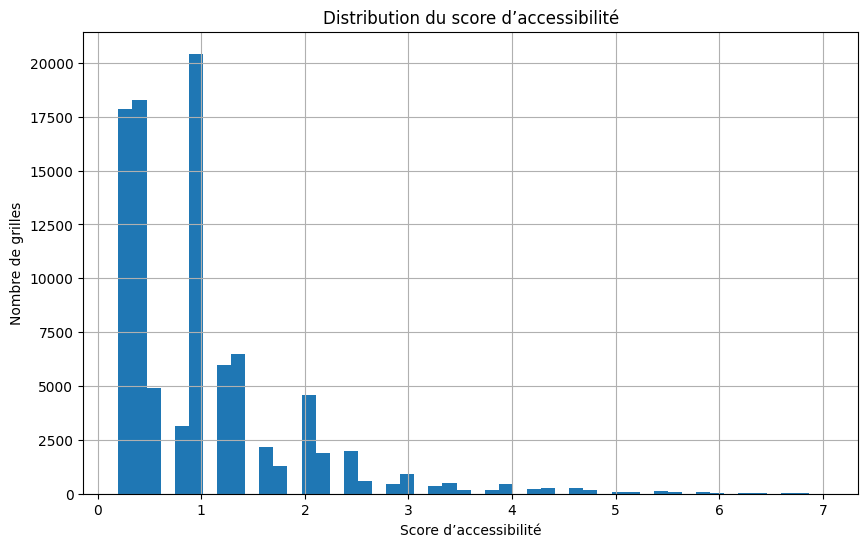

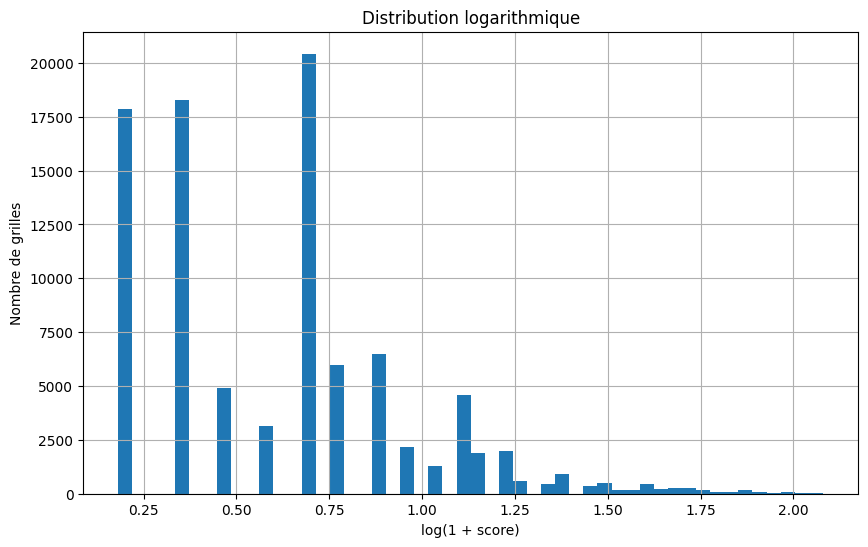

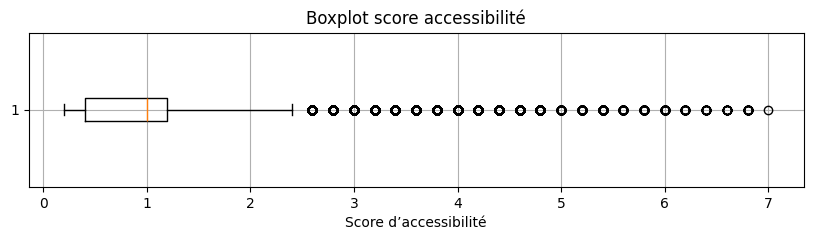

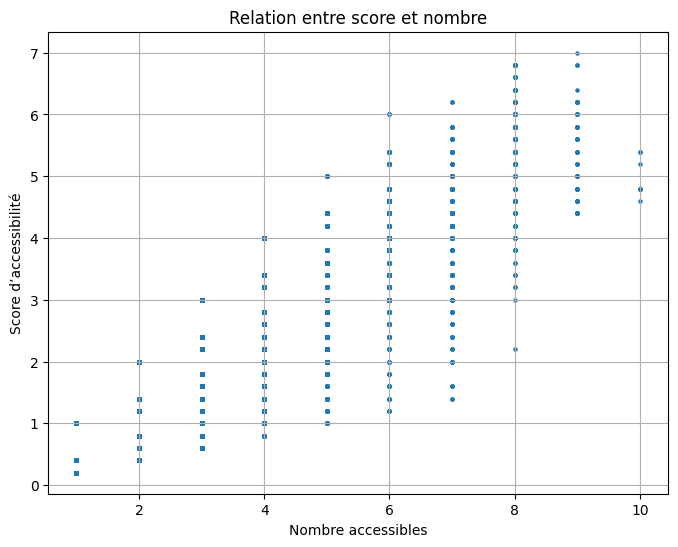


METHODOLOGIE

Analyse exploratoire réalisée
avant classification.

Méthodes utilisées :

- statistiques descriptives
- quantiles
- histogrammes
- boxplot
- corrélation
- dispersion

Objectifs :

identifier :

- asymétrie
- concentration spatiale
- hypercentralité
- valeurs extrêmes
- influence du nombre
  d’établissements accessibles
- influence de la distance

La méthode de classification
sera choisie après analyse
de la distribution observée.



In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =========================================================
# (1) CHARGEMENT
# =========================================================
file_path = "/content/grille_finale_covoiturage.gpkg"

gdf = gpd.read_file(file_path)

print("\n==============================")
print("COUCHE : AUTRES ETUDES")
print("=============================")

print("Nombre de colonnes :", len(gdf.columns))
print("Colonnes :", list(gdf.columns))
print("CRS :", gdf.crs)

# =========================================================
# (2) VERIFICATION
# =========================================================
print("\n=============================")
print("APERÇU")
print("=============================")

print(
    gdf[
        [
            "idINSPIRE",
            "score_access",
            "nb_accessibles"
        ]
    ].head()
)

# =========================================================
# (3) STATISTIQUES GENERALES
# =========================================================
print("\n=============================")
print("STATISTIQUES GENERALES")
print("=============================")

stats = gdf["score_access"].describe()

print(stats)

# =========================================================
# (4) NB GRILLES AVEC / SANS ACCESSIBILITE
# =========================================================
print("\n=============================")
print("GRILLES AVEC / SANS ACCESSIBILITE")
print("=============================")

nb_zero = (
    gdf["score_access"] == 0
).sum()

nb_nonzero = (
    gdf["score_access"] > 0
).sum()

print("Sans accessibilité :", nb_zero)
print("Avec accessibilité :", nb_nonzero)

# =========================================================
# (5) STATISTIQUES SANS ZERO
# =========================================================
gdf_nonzero = gdf[
    gdf["score_access"] > 0
].copy()

print("\n=============================")
print("STATISTIQUES SANS ZERO")
print("=============================")

stats_nonzero = (
    gdf_nonzero["score_access"]
    .describe()
)

print(stats_nonzero)

# =========================================================
# (6) QUANTILES
# =========================================================
print("\n=============================")
print("QUANTILES SANS ZERO")
print("=============================")

quantiles = (
    gdf_nonzero["score_access"]
    .quantile([
        0,
        0.05,
        0.10,
        0.20,
        0.40,
        0.60,
        0.80,
        0.90,
        0.95,
        0.99,
        1
    ])
)

print(quantiles)

# =========================================================
# (7) TOP SCORES
# =========================================================
print("\n=============================")
print("TOP 20 SCORES")
print("=============================")

print(
    gdf_nonzero["score_access"]
    .sort_values(ascending=False)
    .head(20)
)

# =========================================================
# (8) NB ETABLISSEMENTS ACCESSIBLES
# =========================================================
print("\n=============================")
print("NB ETABLISSEMENTS ACCESSIBLES")
print("=============================")

print(
    gdf_nonzero[
        "nb_accessibles"
    ]
    .value_counts()
    .sort_index()
)

# =========================================================
# (9) CORRELATION
# =========================================================
print("\n=============================")
print("CORRELATION")
print("=============================")

correlation = gdf_nonzero[
    [
        "score_access",
        "nb_accessibles"
    ]
].corr()

print(correlation)

# =========================================================
# (10) REPARTITION PAR DISTANCE
# =========================================================
print("\n=============================")
print("REPARTITION PAR DISTANCE")
print("=============================")

dist_cols = [
    "dist_1000",
    "dist_2000",
    "dist_3000",
    "dist_4000",
    "dist_5000"
]

for c in dist_cols:

    total = (
        gdf_nonzero[c]
        .sum()
    )

    print(c, ":", int(total))

# =========================================================
# (11) HISTOGRAMME
# =========================================================
plt.figure(figsize=(10,6))

plt.hist(
    gdf_nonzero["score_access"],
    bins=50
)

plt.xlabel("Score d’accessibilité")
plt.ylabel("Nombre de grilles")

plt.title(
    "Distribution du score d’accessibilité"
)

plt.grid()

plt.show()

# =========================================================
# (12) HISTOGRAMME LOG
# =========================================================
plt.figure(figsize=(10,6))

plt.hist(
    np.log1p(
        gdf_nonzero["score_access"]
    ),
    bins=50
)

plt.xlabel("log(1 + score)")
plt.ylabel("Nombre de grilles")

plt.title(
    "Distribution logarithmique"
)

plt.grid()

plt.show()

# =========================================================
# (13) BOXPLOT
# =========================================================
plt.figure(figsize=(10,2))

plt.boxplot(
    gdf_nonzero["score_access"],
    vert=False
)

plt.xlabel("Score d’accessibilité")

plt.title(
    "Boxplot score accessibilité"
)

plt.grid()

plt.show()

# =========================================================
# (14) DISPERSION
# =========================================================
plt.figure(figsize=(8,6))

plt.scatter(
    gdf_nonzero[
        "nb_accessibles"
    ],
    gdf_nonzero["score_access"],
    s=5
)

plt.xlabel(
    "Nombre accessibles"
)

plt.ylabel(
    "Score d’accessibilité"
)

plt.title(
    "Relation entre score et nombre"
)

plt.grid()

plt.show()

# =========================================================
# (15) METHODOLOGIE
# =========================================================
print("\n=============================")
print("METHODOLOGIE")
print("=============================")

print("""
Analyse exploratoire réalisée
avant classification.

Méthodes utilisées :

- statistiques descriptives
- quantiles
- histogrammes
- boxplot
- corrélation
- dispersion

Objectifs :

identifier :

- asymétrie
- concentration spatiale
- hypercentralité
- valeurs extrêmes
- influence du nombre
  d’établissements accessibles
- influence de la distance

La méthode de classification
sera choisie après analyse
de la distribution observée.
""")

# **f Location vélo**

## grille finale

In [ ]:
import geopandas as gpd
import pandas as pd

# =========================================================
# (1) CHARGEMENT ISOCHRONES
# =========================================================
iso_file = (
    "/content/"
    "isodistance_ors_loc_velo_1_5_km.gpkg"
)

gdf_iso = gpd.read_file(iso_file)

print("\n==============================")
print("ISOCHRONES AUTRES ETUDES")
print("==============================")

print("Colonnes :", list(gdf_iso.columns))
print("CRS :", gdf_iso.crs)

# =========================================================
# (2) CHARGEMENT GRILLE
# =========================================================
grid_file = (
    "/content/"
    "grille_alsace_sans_massifs.gpkg"
)

gdf_grid = gpd.read_file(grid_file)

print("\n==============================")
print("GRILLE")
print("==============================")

print("Colonnes :", list(gdf_grid.columns))
print("CRS :", gdf_grid.crs)

# =========================================================
# (3) MEME CRS
# =========================================================
if gdf_iso.crs != gdf_grid.crs:

    gdf_iso = gdf_iso.to_crs(
        gdf_grid.crs
    )

# =========================================================
# (4) INTERSECTION
# =========================================================
print("\n==============================")
print("INTERSECTION")
print("==============================")

gdf = gpd.overlay(
    gdf_grid,
    gdf_iso,
    how="intersection"
)

print("Nb intersections :", len(gdf))

# =========================================================
# (5) SURFACE INTERSECTION
# =========================================================
gdf["area"] = gdf.geometry.area

# =========================================================
# (6) APERCU
# =========================================================
print("\n==============================")
print("APERÇU")
print("==============================")

print(
    gdf[
        [
            "idINSPIRE",
            "name",
            "AA_METERS",
            "area"
        ]
    ].head()
)

# =========================================================
# (7) AGRÉGATION
# =========================================================
grouped = (
    gdf.groupby(
        [
            "idINSPIRE",
            "name",
            "AA_METERS"
        ],
        as_index=False
    )["area"]
    .sum()
)

print("\n==============================")
print("TABLE AGRÉGÉE")
print("==============================")

print(grouped.head())

# =========================================================
# (8) SURFACE TOTALE
# PAR GRILLE + ETABLISSEMENT
# =========================================================
sum_total = (
    grouped.groupby(
        [
            "idINSPIRE",
            "name"
        ],
        as_index=False
    )["area"]
    .sum()
    .rename(
        columns={
            "area": "sum_area"
        }
    )
)

# =========================================================
# (9) VALIDATION
# =========================================================
THRESHOLD = 20000

sum_total["valid"] = (
    sum_total["sum_area"]
    > THRESHOLD
)

valid_pairs = (
    sum_total[
        sum_total["valid"]
    ][
        [
            "idINSPIRE",
            "name"
        ]
    ]
)

print("\n==============================")
print("NB COUPLES VALIDES")
print("==============================")

print(len(valid_pairs))

# =========================================================
# (10) GARDER VALIDES
# =========================================================
grouped_valid = grouped.merge(
    valid_pairs,
    on=[
        "idINSPIRE",
        "name"
    ],
    how="inner"
)

# =========================================================
# (11) DISTANCE MINIMALE
# =========================================================
minimal = (
    grouped_valid.groupby(
        [
            "idINSPIRE",
            "name"
        ],
        as_index=False
    )["AA_METERS"]
    .min()
)

print("\n==============================")
print("DISTANCE MINIMALE")
print("==============================")

print(minimal.head())

# =========================================================
# (12) EXPORT CONTROLE
# =========================================================
minimal.to_csv(
    "/content/distance_minimale_location_velo.csv",
    index=False
)

# =========================================================
# (13) TABLEAU CROISÉ
# =========================================================
pivot = pd.pivot_table(
    minimal,
    index="idINSPIRE",
    columns="AA_METERS",
    values="name",
    aggfunc="count",
    fill_value=0
)

# =========================================================
# (14) RENOMMER
# =========================================================
pivot = pivot.rename(
    columns={
        1000: "dist_1000",
        2000: "dist_2000",
        3000: "dist_3000",
        4000: "dist_4000",
        5000: "dist_5000"
    }
)

pivot = pivot.reset_index()

# =========================================================
# (15) COLONNES MANQUANTES
# =========================================================
wanted = [
    "dist_1000",
    "dist_2000",
    "dist_3000",
    "dist_4000",
    "dist_5000"
]

for c in wanted:

    if c not in pivot.columns:

        pivot[c] = 0

pivot = pivot[
    ["idINSPIRE"] + wanted
]

# =========================================================
# (16) SCORE
# =========================================================
pivot["score_access"] = (
      pivot["dist_1000"] * 1
    + pivot["dist_2000"] * 1
    + pivot["dist_3000"] * 1
    + pivot["dist_4000"] * 0.4
    + pivot["dist_5000"] * 0.2
)

# =========================================================
# (17) NB ACCESSIBLES
# =========================================================
pivot["nb_accessibles"] = (
      pivot["dist_1000"]
    + pivot["dist_2000"]
    + pivot["dist_3000"]
    + pivot["dist_4000"]
    + pivot["dist_5000"]
)

print("\n==============================")
print("TABLEAU FINAL")
print("==============================")

print(pivot.head())

# =========================================================
# (18) JOINTURE FINALE
# =========================================================
gdf_grid["idINSPIRE"] = (
    gdf_grid["idINSPIRE"]
    .astype(str)
)

pivot["idINSPIRE"] = (
    pivot["idINSPIRE"]
    .astype(str)
)

gdf_final = gdf_grid.merge(
    pivot,
    on="idINSPIRE",
    how="left"
)

# =========================================================
# (19) NULL -> 0
# =========================================================
for c in wanted:

    gdf_final[c] = (
        gdf_final[c]
        .fillna(0)
    )

gdf_final["score_access"] = (
    gdf_final["score_access"]
    .fillna(0)
)

gdf_final["nb_accessibles"] = (
    gdf_final["nb_accessibles"]
    .fillna(0)
)

# =========================================================
# (20) EXPORT
# =========================================================
output = (
    "/content/"
    "grille_finale_location_velo.gpkg"
)

gdf_final.to_file(
    output,
    driver="GPKG"
)

print("\n==============================")
print("EXPORT FINAL")
print("==============================")

print(output)

print("\nNB GRILLES :", len(gdf_final))

print(
    gdf_final[
        [
            "idINSPIRE",
            "score_access",
            "nb_accessibles"
        ]
    ].head()
)


ISOCHRONES AUTRES ETUDES
Colonnes : ['name', 'AA_METERS', 'geometry']
CRS : EPSG:4326

GRILLE
Colonnes : ['idINSPIRE', 'geometry']
CRS : EPSG:3948

INTERSECTION
Nb intersections : 383611

APERÇU
                        idINSPIRE     name  AA_METERS          area
0  CRS3035RES200mN2772200E4102600  Munster       5000   3603.328882
1  CRS3035RES200mN2772000E4102600  Munster       5000   7924.692181
2  CRS3035RES200mN2771800E4102600  Munster       5000   1286.643651
3  CRS3035RES200mN2772400E4102800  Munster       5000   3875.818182
4  CRS3035RES200mN2772200E4102800  Munster       5000  33082.197922

TABLE AGRÉGÉE
                        idINSPIRE         name  AA_METERS         area
0  CRS3035RES200mN2718800E4135600  Saint-Louis       5000  1213.190584
1  CRS3035RES200mN2719000E4134600  Saint-Louis       5000    65.933771
2  CRS3035RES200mN2719000E4134800  Saint-Louis       5000  7348.668049
3  CRS3035RES200mN2719000E4135000  Saint-Louis       5000  8524.860301
4  CRS3035RES200mN2719000E

## statistique


COUCHE : AUTRES ETUDES
Nombre de colonnes : 9
Colonnes : ['idINSPIRE', 'dist_1000', 'dist_2000', 'dist_3000', 'dist_4000', 'dist_5000', 'score_access', 'nb_accessibles', 'geometry']
CRS : EPSG:3948

APERÇU
                        idINSPIRE  score_access  nb_accessibles
0  CRS3035RES200mN2748800E4088000           0.0             0.0
1  CRS3035RES200mN2748600E4088000           0.0             0.0
2  CRS3035RES200mN2748400E4088000           0.0             0.0
3  CRS3035RES200mN2748200E4088000           0.0             0.0
4  CRS3035RES200mN2749200E4088200           0.0             0.0

STATISTIQUES GENERALES
count    182455.000000
mean          0.503925
std           3.034221
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          49.600000
Name: score_access, dtype: float64

GRILLES AVEC / SANS ACCESSIBILITE
Sans accessibilité : 152272
Avec accessibilité : 30183

STATISTIQUES SANS ZERO
count    30183.000000
mean         3.046205
std     

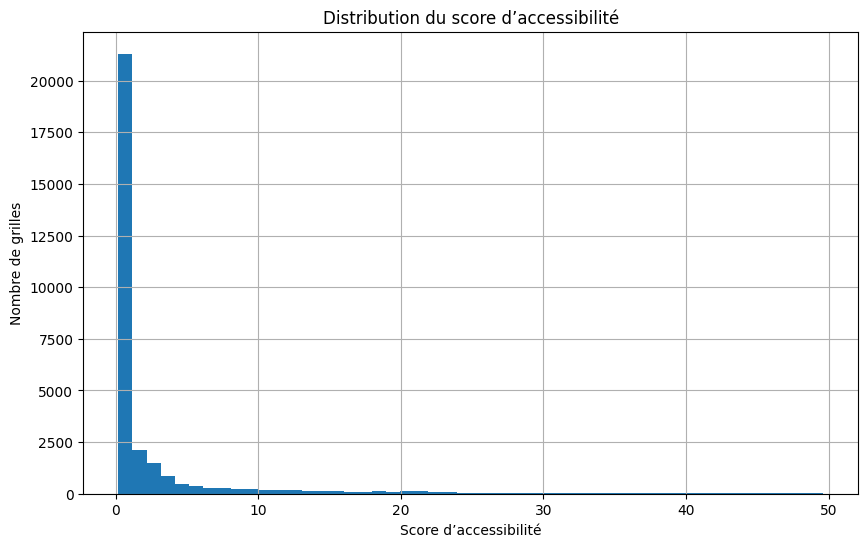

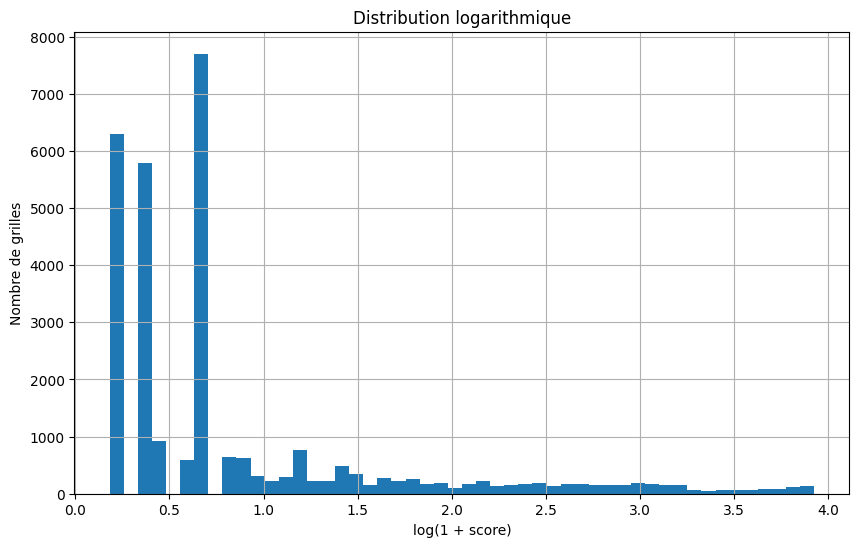

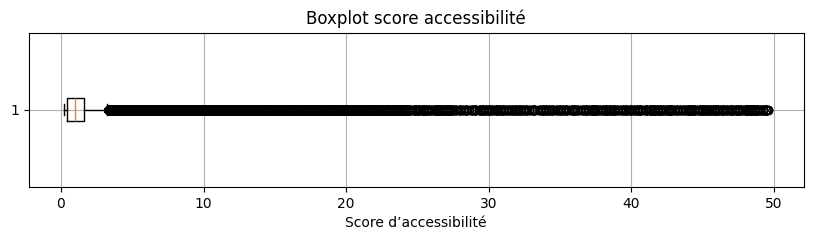

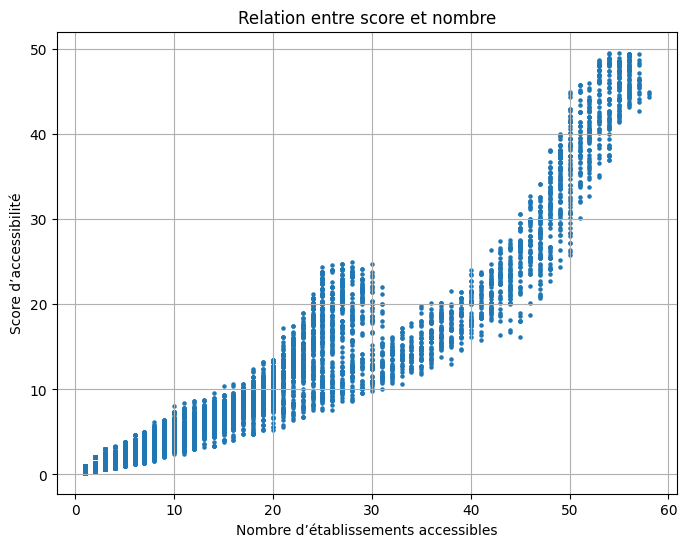


METHODOLOGIE

Analyse exploratoire réalisée
avant classification.

Méthodes utilisées :

- statistiques descriptives
- quantiles
- histogrammes
- boxplot
- corrélation
- dispersion

Objectifs :

identifier :

- asymétrie
- concentration spatiale
- hypercentralité
- valeurs extrêmes
- influence du nombre
  d’établissements accessibles
- influence de la distance

La méthode de classification
sera choisie après analyse
de la distribution observée.



In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =========================================================
# (1) CHARGEMENT
# =========================================================
file_path = "/content/grille_finale_location_velo.gpkg"

gdf = gpd.read_file(file_path)

print("\n==============================")
print("COUCHE : AUTRES ETUDES")
print("=============================")

print("Nombre de colonnes :", len(gdf.columns))
print("Colonnes :", list(gdf.columns))
print("CRS :", gdf.crs)

# =========================================================
# (2) VERIFICATION
# =========================================================
print("\n=============================")
print("APERÇU")
print("=============================")

print(
    gdf[
        [
            "idINSPIRE",
            "score_access",
            "nb_accessibles"
        ]
    ].head()
)

# =========================================================
# (3) STATISTIQUES GENERALES
# =========================================================
print("\n=============================")
print("STATISTIQUES GENERALES")
print("=============================")

stats = gdf["score_access"].describe()

print(stats)

# =========================================================
# (4) NB GRILLES AVEC / SANS ACCESSIBILITE
# =========================================================
print("\n=============================")
print("GRILLES AVEC / SANS ACCESSIBILITE")
print("=============================")

nb_zero = (
    gdf["score_access"] == 0
).sum()

nb_nonzero = (
    gdf["score_access"] > 0
).sum()

print("Sans accessibilité :", nb_zero)
print("Avec accessibilité :", nb_nonzero)

# =========================================================
# (5) STATISTIQUES SANS ZERO
# =========================================================
gdf_nonzero = gdf[
    gdf["score_access"] > 0
].copy()

print("\n=============================")
print("STATISTIQUES SANS ZERO")
print("=============================")

stats_nonzero = (
    gdf_nonzero["score_access"]
    .describe()
)

print(stats_nonzero)

# =========================================================
# (6) QUANTILES
# =========================================================
print("\n=============================")
print("QUANTILES SANS ZERO")
print("=============================")

quantiles = (
    gdf_nonzero["score_access"]
    .quantile([
        0,
        0.05,
        0.10,
        0.20,
        0.40,
        0.60,
        0.80,
        0.90,
        0.95,
        0.99,
        1
    ])
)

print(quantiles)

# =========================================================
# (7) TOP SCORES
# =========================================================
print("\n=============================")
print("TOP 20 SCORES")
print("=============================")

print(
    gdf_nonzero["score_access"]
    .sort_values(ascending=False)
    .head(20)
)

# =========================================================
# (8) NB ETABLISSEMENTS ACCESSIBLES
# =========================================================
print("\n=============================")
print("NB ETABLISSEMENTS ACCESSIBLES")
print("=============================")

print(
    gdf_nonzero[
        "nb_accessibles"
    ]
    .value_counts()
    .sort_index()
)

# =========================================================
# (9) CORRELATION
# =========================================================
print("\n=============================")
print("CORRELATION")
print("=============================")

correlation = gdf_nonzero[
    [
        "score_access",
        "nb_accessibles"
    ]
].corr()

print(correlation)

# =========================================================
# (10) REPARTITION PAR DISTANCE
# =========================================================
print("\n=============================")
print("REPARTITION PAR DISTANCE")
print("=============================")

dist_cols = [
    "dist_1000",
    "dist_2000",
    "dist_3000",
    "dist_4000",
    "dist_5000"
]

for c in dist_cols:

    total = (
        gdf_nonzero[c]
        .sum()
    )

    print(c, ":", int(total))

# =========================================================
# (11) HISTOGRAMME
# =========================================================
plt.figure(figsize=(10,6))

plt.hist(
    gdf_nonzero["score_access"],
    bins=50
)

plt.xlabel("Score d’accessibilité")
plt.ylabel("Nombre de grilles")

plt.title(
    "Distribution du score d’accessibilité"
)

plt.grid()

plt.show()

# =========================================================
# (12) HISTOGRAMME LOG
# =========================================================
plt.figure(figsize=(10,6))

plt.hist(
    np.log1p(
        gdf_nonzero["score_access"]
    ),
    bins=50
)

plt.xlabel("log(1 + score)")
plt.ylabel("Nombre de grilles")

plt.title(
    "Distribution logarithmique"
)

plt.grid()

plt.show()

# =========================================================
# (13) BOXPLOT
# =========================================================
plt.figure(figsize=(10,2))

plt.boxplot(
    gdf_nonzero["score_access"],
    vert=False
)

plt.xlabel("Score d’accessibilité")

plt.title(
    "Boxplot score accessibilité"
)

plt.grid()

plt.show()

# =========================================================
# (14) DISPERSION
# =========================================================
plt.figure(figsize=(8,6))

plt.scatter(
    gdf_nonzero[
        "nb_accessibles"
    ],
    gdf_nonzero["score_access"],
    s=5
)

plt.xlabel(
    "Nombre d’établissements accessibles"
)

plt.ylabel(
    "Score d’accessibilité"
)

plt.title(
    "Relation entre score et nombre"
)

plt.grid()

plt.show()

# =========================================================
# (15) METHODOLOGIE
# =========================================================
print("\n=============================")
print("METHODOLOGIE")
print("=============================")

print("""
Analyse exploratoire réalisée
avant classification.

Méthodes utilisées :

- statistiques descriptives
- quantiles
- histogrammes
- boxplot
- corrélation
- dispersion

Objectifs :

identifier :

- asymétrie
- concentration spatiale
- hypercentralité
- valeurs extrêmes
- influence du nombre
  d’établissements accessibles
- influence de la distance

La méthode de classification
sera choisie après analyse
de la distribution observée.
""")